In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')



# ============================================================
# PARTIE 1: CHARGEMENT ET PRÉPARATION DES DONNÉES
# ============================================================

In [4]:
print("="*80)
print("CHARGEMENT ET ANALYSE DES DONNÉES D'ÉCLAIRS")
print("="*80)

# Configuration des styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Chargement des données
print("\n[1] Chargement du fichier CSV...")
df = pd.read_csv('data_train_databattle2026\\segment_alerts_all_airports_train.csv', 
                 parse_dates=['date'],
                 low_memory=False)

print(f"Nombre total d'éclairs: {len(df):,}")
print(f"Période: {df['date'].min()} à {df['date'].max()}")
print(f"Aéroports présents: {df['airport'].unique()}")

CHARGEMENT ET ANALYSE DES DONNÉES D'ÉCLAIRS

[1] Chargement du fichier CSV...
Nombre total d'éclairs: 507,071
Période: 2016-01-02 01:10:41+00:00 à 2022-12-21 11:20:11+00:00
Aéroports présents: ['Ajaccio' 'Bastia' 'Biarritz' 'Nantes' 'Pise']


# ============================================================
# PARTIE 2: ANALYSE EXPLORATOIRE DES DONNÉES (EDA)
# ============================================================

In [5]:
print("\n[2] ANALYSE EXPLORATOIRE DES DONNÉES")
print("-" * 50)

# Statistiques descriptives
print("\n2.1 Statistiques descriptives:")
print(df[['amplitude', 'maxis', 'dist', 'azimuth']].describe())

# Distribution des types d'éclairs
print("\n2.2 Distribution des types d'éclairs:")
icloud_dist = df['icloud'].value_counts()
print(f"Éclairs intra-nuage (True): {icloud_dist.get(True, 0):,} ({icloud_dist.get(True, 0)/len(df)*100:.1f}%)")
print(f"Éclairs nuage-sol (False): {icloud_dist.get(False, 0):,} ({icloud_dist.get(False, 0)/len(df)*100:.1f}%)")

# Analyse des alertes
print("\n2.3 Analyse des alertes:")
df_alertes = df[df['airport_alert_id'].notna()].copy()
print(f"Éclairs dans des alertes: {len(df_alertes):,} ({len(df_alertes)/len(df)*100:.1f}%)")
print(f"Nombre d'alertes uniques: {df_alertes['airport_alert_id'].nunique():,}")

# Distribution des éclairs par alerte
alertes_counts = df_alertes.groupby('airport_alert_id').size()
print(f"Moyenne d'éclairs par alerte: {alertes_counts.mean():.1f}")
print(f"Médiane d'éclairs par alerte: {alertes_counts.median():.1f}")
print(f"Max d'éclairs dans une alerte: {alertes_counts.max()}")

# Analyse de la cible (is_last_lightning_cloud_ground)
print("\n2.4 Analyse de la variable cible (fin d'orage):")
cible_dist = df['is_last_lightning_cloud_ground'].value_counts()
total_cible = len(df[df['is_last_lightning_cloud_ground'].notna()])
print(f"Vrai (fin d'orage): {cible_dist.get(True, 0):,} ({cible_dist.get(True, 0)/total_cible*100:.1f}% des alertes)")
print(f"Faux: {cible_dist.get(False, 0):,} ({cible_dist.get(False, 0)/total_cible*100:.1f}%)")
print(f"Taux de déséquilibre: {cible_dist.get(False, 0)/cible_dist.get(True, 0):.1f}:1")




[2] ANALYSE EXPLORATOIRE DES DONNÉES
--------------------------------------------------

2.1 Statistiques descriptives:
           amplitude          maxis           dist        azimuth
count  507071.000000  507071.000000  507071.000000  507071.000000
mean       -2.254868       1.025518      20.243757     168.806028
std        20.252913       1.359688       6.941580      97.587294
min      -429.500000       0.016000       0.037212       0.000000
25%        -5.610000       0.107000      15.412370      85.240722
50%        -1.560000       0.245000      21.442300     156.717299
75%         4.620000       1.538000      26.112228     251.482192
max       497.000000       6.900000      29.999996     359.978549

2.2 Distribution des types d'éclairs:
Éclairs intra-nuage (True): 378,079 (74.6%)
Éclairs nuage-sol (False): 128,992 (25.4%)

2.3 Analyse des alertes:
Éclairs dans des alertes: 56,599 (11.2%)
Nombre d'alertes uniques: 769
Moyenne d'éclairs par alerte: 73.6
Médiane d'éclairs par alert

# ============================================================
# PARTIE 3: VISUALISATIONS EXPLORATOIRES
# ============================================================


[3] CRÉATION DES VISUALISATIONS
--------------------------------------------------


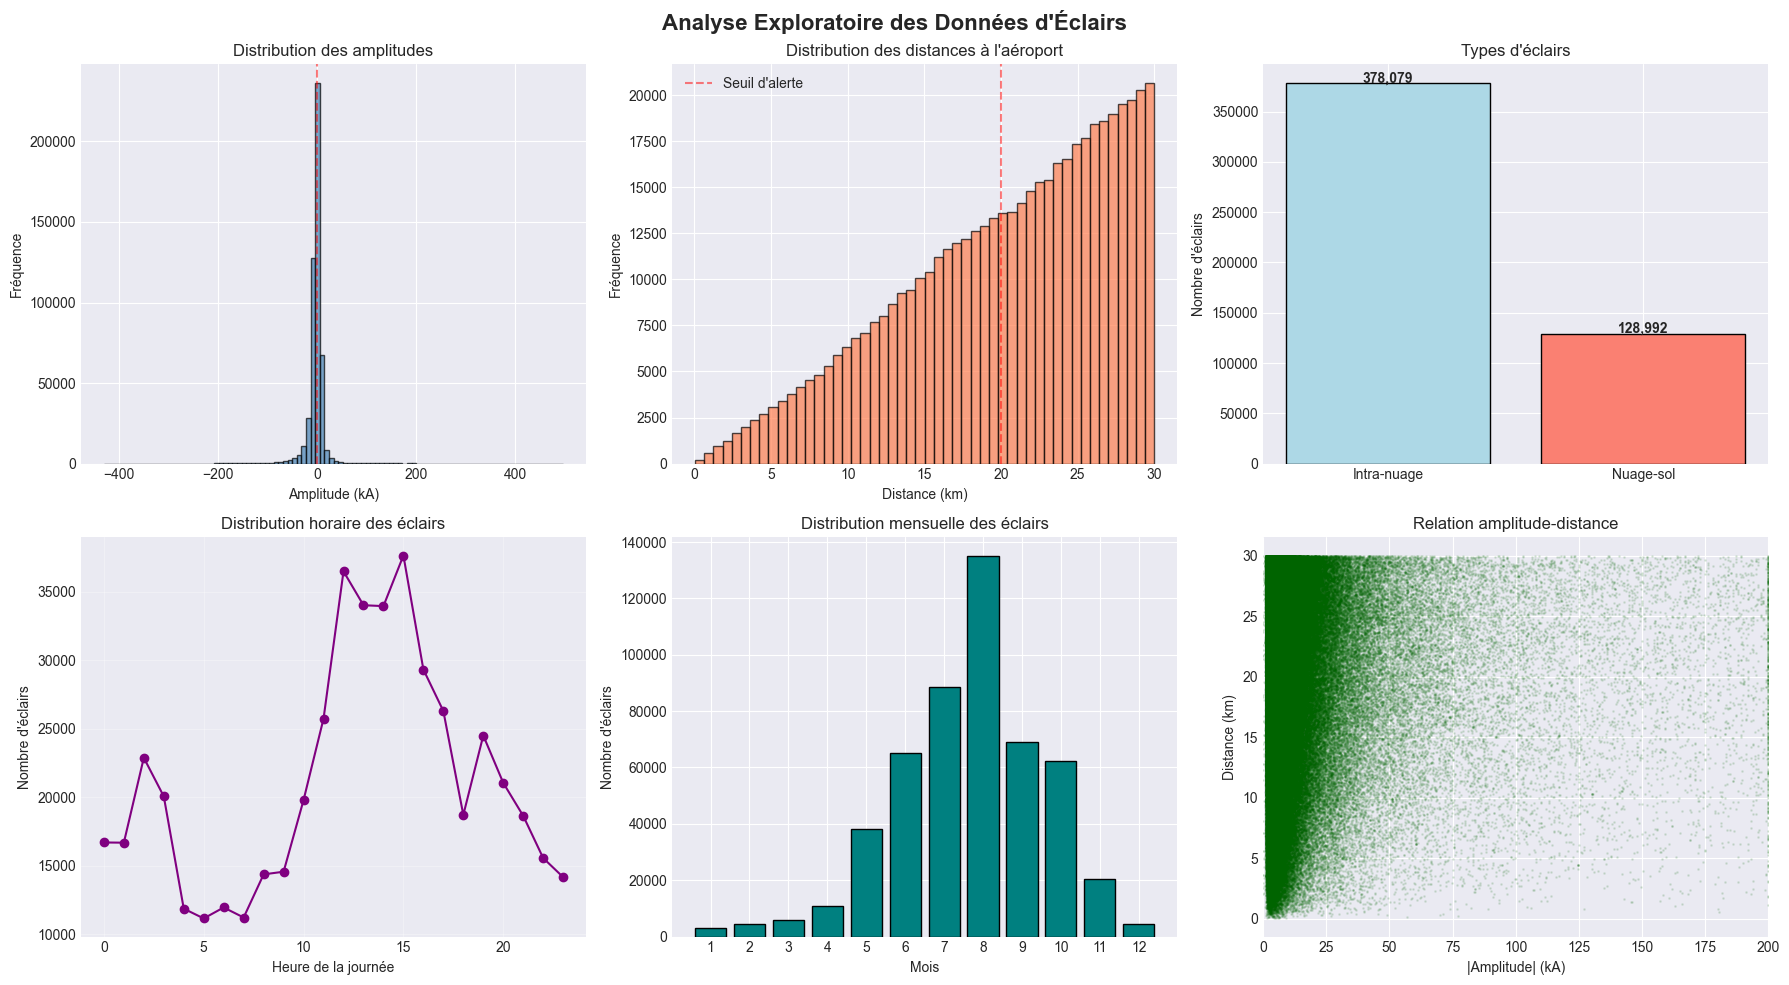

✓ Visualisations sauvegardées dans 'eda_lightning_analysis.png'


In [6]:
print("\n[3] CRÉATION DES VISUALISATIONS")
print("-" * 50)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Analyse Exploratoire des Données d\'Éclairs', fontsize=16, fontweight='bold')

# 1. Distribution des amplitudes
axes[0,0].hist(df['amplitude'].dropna(), bins=100, alpha=0.7, color='steelblue', edgecolor='black')
axes[0,0].set_xlabel('Amplitude (kA)')
axes[0,0].set_ylabel('Fréquence')
axes[0,0].set_title('Distribution des amplitudes')
axes[0,0].axvline(x=0, color='red', linestyle='--', alpha=0.5)

# 2. Distance par rapport à l'aéroport
axes[0,1].hist(df['dist'].dropna(), bins=50, alpha=0.7, color='coral', edgecolor='black')
axes[0,1].set_xlabel('Distance (km)')
axes[0,1].set_ylabel('Fréquence')
axes[0,1].set_title('Distribution des distances à l\'aéroport')
axes[0,1].axvline(x=20, color='red', linestyle='--', alpha=0.5, label='Seuil d\'alerte')
axes[0,1].legend()

# 3. Types d'éclairs
icloud_counts = df['icloud'].value_counts()
axes[0,2].bar(['Intra-nuage', 'Nuage-sol'], icloud_counts.values, 
              color=['lightblue', 'salmon'], edgecolor='black')
axes[0,2].set_ylabel('Nombre d\'éclairs')
axes[0,2].set_title('Types d\'éclairs')
for i, v in enumerate(icloud_counts.values):
    axes[0,2].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# 4. Distribution temporelle
df['hour'] = df['date'].dt.hour
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

hour_counts = df.groupby('hour').size()
axes[1,0].plot(hour_counts.index, hour_counts.values, marker='o', linestyle='-', color='purple')
axes[1,0].set_xlabel('Heure de la journée')
axes[1,0].set_ylabel('Nombre d\'éclairs')
axes[1,0].set_title('Distribution horaire des éclairs')
axes[1,0].grid(True, alpha=0.3)

# 5. Distribution mensuelle
month_counts = df.groupby('month').size()
axes[1,1].bar(month_counts.index, month_counts.values, color='teal', edgecolor='black')
axes[1,1].set_xlabel('Mois')
axes[1,1].set_ylabel('Nombre d\'éclairs')
axes[1,1].set_title('Distribution mensuelle des éclairs')
axes[1,1].set_xticks(range(1,13))

# 6. Corrélation amplitude-distance
axes[1,2].scatter(df['amplitude'].abs().clip(upper=200), df['dist'], 
                 alpha=0.1, s=1, c='darkgreen')
axes[1,2].set_xlabel('|Amplitude| (kA)')
axes[1,2].set_ylabel('Distance (km)')
axes[1,2].set_title('Relation amplitude-distance')
axes[1,2].set_xlim(0, 200)

plt.tight_layout()
plt.savefig('eda_lightning_analysis.png', dpi=150)
plt.show()
print("✓ Visualisations sauvegardées dans 'eda_lightning_analysis.png'")



# ============================================================
# PARTIE 4: ANALYSE SPATIO-TEMPORELLE
# ============================================================

In [7]:
print("\n[4] ANALYSE SPATIO-TEMPORELLE DES ORAGES")
print("-" * 50)

# Analyse par aéroport
print("\n4.1 Statistiques par aéroport:")
airport_stats = df.groupby('airport').agg({
    'lightning_id': 'count',
    'amplitude': ['mean', 'std', 'min', 'max'],
    'dist': 'mean',
    'icloud': lambda x: (x == False).sum()  # Nombre d'éclairs nuage-sol
}).round(2)

airport_stats.columns = ['total', 'amp_mean', 'amp_std', 'amp_min', 'amp_max', 'dist_mean', 'cg_count']
print(airport_stats)

# Création de features temporelles pour les alertes
print("\n4.2 Analyse des séquences d'alertes...")
df_alertes = df[df['airport_alert_id'].notna()].copy()
df_alertes = df_alertes.sort_values(['airport', 'airport_alert_id', 'date'])

# Calcul des intervalles entre éclairs dans une alerte
df_alertes['time_diff'] = df_alertes.groupby(['airport', 'airport_alert_id'])['date'].diff().dt.total_seconds()

# Statistiques des intervalles
intervalles = df_alertes['time_diff'].dropna()
print(f"\nIntervalles entre éclairs dans une alerte:")
print(f"Moyenne: {intervalles.mean():.1f} secondes")
print(f"Médiane: {intervalles.median():.1f} secondes")
print(f"Écart-type: {intervalles.std():.1f} secondes")



[4] ANALYSE SPATIO-TEMPORELLE DES ORAGES
--------------------------------------------------

4.1 Statistiques par aéroport:
           total  amp_mean  amp_std  amp_min  amp_max  dist_mean  cg_count
airport                                                                   
Ajaccio    72501     -3.42    22.43  -425.02   344.31      20.37     24048
Bastia    125919     -1.94    21.01  -429.50   497.00      20.56     33309
Biarritz  115191     -1.64    16.04  -377.59   350.14      19.84     21231
Nantes     36742     -3.43    29.00  -315.83   482.00      19.82      9549
Pise      156718     -2.14    18.77  -361.20   350.40      20.33     40855

4.2 Analyse des séquences d'alertes...

Intervalles entre éclairs dans une alerte:
Moyenne: 87.3 secondes
Médiane: 24.0 secondes
Écart-type: 191.8 secondes


# ============================================================
# PARTIE 5: MACHINE LEARNING - PRÉDICTION DE FIN D'ORAGE
# ============================================================

In [9]:
print("\n[5] MACHINE LEARNING - PRÉDICTION DE FIN D'ORAGE")
print("-" * 50)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                           roc_auc_score, f1_score, precision_recall_curve,
                           average_precision_score, make_scorer)
import xgboost as xgb

# 5.1 Préparation des données
print("\n5.1 Préparation des features pour le ML...")

df_ml = df[df['is_last_lightning_cloud_ground'].notna()].copy()
print(f"Échantillon d'entraînement: {len(df_ml):,} éclairs étiquetés")

df_ml = df_ml.sort_values(['airport', 'airport_alert_id', 'date'])

# Features par alerte
features_alerte = df_ml.groupby(['airport', 'airport_alert_id']).agg({
    'date': ['min', 'max', 'count'],
    'amplitude': ['mean', 'std', 'min', 'max'],
    'maxis': 'mean',
    'dist': ['mean', 'min', 'max', 'std'],
    'icloud': lambda x: (x == False).sum(),
}).reset_index()

features_alerte.columns = ['airport', 'alert_id', 
                          'start_time', 'end_time', 'n_strikes',
                          'amp_mean', 'amp_std', 'amp_min', 'amp_max',
                          'maxis_mean',
                          'dist_mean', 'dist_min', 'dist_max', 'dist_std',
                          'cg_count']

# Features additionnelles
features_alerte['duration'] = (features_alerte['end_time'] - features_alerte['start_time']).dt.total_seconds()
features_alerte['cg_ratio'] = features_alerte['cg_count'] / features_alerte['n_strikes']
features_alerte['intensity_range'] = features_alerte['amp_max'] - features_alerte['amp_min']
features_alerte['strike_rate'] = features_alerte['n_strikes'] / features_alerte['duration'].clip(lower=1)

# Fusion avec la cible
targets = df_ml.groupby(['airport', 'airport_alert_id']).agg({
    'is_last_lightning_cloud_ground': 'last'
}).reset_index()
targets.columns = ['airport', 'alert_id', 'target']

df_features = features_alerte.merge(targets, on=['airport', 'alert_id'])

print(f"Nombre d'alertes: {len(df_features)}")
print(f"Distribution de la cible:")
print(df_features['target'].value_counts())

# Encodage des aéroports
le = LabelEncoder()
df_features['airport_encoded'] = le.fit_transform(df_features['airport'])

# Sélection des features
feature_cols = ['n_strikes', 'duration', 'cg_count', 'cg_ratio', 'strike_rate',
                'amp_mean', 'amp_std', 'amp_min', 'amp_max', 'intensity_range',
                'maxis_mean', 'dist_mean', 'dist_std', 'dist_min', 'dist_max',
                'airport_encoded']

X = df_features[feature_cols].fillna(0)
y = df_features['target'].astype(int)

print(f"\nFeatures utilisées: {len(feature_cols)} variables")
print(f"X shape: {X.shape}")
print(f"Distribution y: 0={sum(y==0)} ({sum(y==0)/len(y)*100:.1f}%), 1={sum(y==1)} ({sum(y==1)/len(y)*100:.1f}%)")

# 5.2 Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {len(X_train)} alertes, Test: {len(X_test)} alertes")

# 5.3 Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5.4 Modèles avec gestion du déséquilibre
print("\n5.4 Entraînement des modèles...")

# Calcul du poids pour la classe minoritaire
scale_pos_weight = sum(y_train==0) / sum(y_train==1)

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_split=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        random_state=42, eval_metric='logloss', use_label_encoder=False
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150, max_depth=5, learning_rate=0.1,
        random_state=42
    )
}

results = {}
for name, model in models.items():
    print(f"\n{name}:")
    
    # Validation croisée simple (sans SMOTE)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    try:
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1')
        print(f"  CV F1-score: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")
    except Exception as e:
        print(f"  Erreur CV: {str(e)[:100]}...")
        cv_scores = np.array([0])
    
    # Entraînement final
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Métriques
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    ap = average_precision_score(y_test, y_pred_proba)
    
    results[name] = {
        'model': model,
        'f1': f1,
        'auc': auc,
        'ap': ap,
        'predictions': y_pred,
        'proba': y_pred_proba
    }
    
    print(f"  Test F1-score: {f1:.3f}")
    print(f"  Test AUC-ROC: {auc:.3f}")
    print(f"  Average Precision: {ap:.3f}")
    print(f"  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Non-fin', 'Fin']))

# 5.5 Comparaison
print("\n5.5 Comparaison des performances:")
results_df = pd.DataFrame({
    name: {'F1-Score': res['f1'], 'AUC-ROC': res['auc'], 'Avg Precision': res['ap']}
    for name, res in results.items()
}).T
print(results_df.round(3))

# Meilleur modèle
best_model_name = max(results, key=lambda x: results[x]['f1'] if results[x]['f1'] > 0 else -1)
best_model = results[best_model_name]['model']
print(f"\nMeilleur modèle: {best_model_name} (F1={results[best_model_name]['f1']:.3f})")

# 5.6 Feature importance
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    print("\n5.6 Importance des features:")
    print(feature_importance.head(10).to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['feature'][:10], feature_importance['importance'][:10])
    plt.xlabel('Importance')
    plt.title(f'Top 10 Features - {best_model_name}')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150)
    plt.show()

# 5.7 Matrice de confusion
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Non-fin', 'Fin'], yticklabels=['Non-fin', 'Fin'])
    axes[idx].set_title(f'{name}\nF1={res["f1"]:.3f}')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()



[5] MACHINE LEARNING - PRÉDICTION DE FIN D'ORAGE
--------------------------------------------------

5.1 Préparation des features pour le ML...
Échantillon d'entraînement: 56,599 éclairs étiquetés
Nombre d'alertes: 2627
Distribution de la cible:
target
True    2627
Name: count, dtype: int64

Features utilisées: 16 variables
X shape: (2627, 16)
Distribution y: 0=0 (0.0%), 1=2627 (100.0%)

Train: 2101 alertes, Test: 526 alertes

5.4 Entraînement des modèles...

Random Forest:
  CV F1-score: 1.000 (+/- 0.000)


IndexError: index 1 is out of bounds for axis 1 with size 1


[6] PROCESSUS STOCHASTIQUE - CHAÎNE DE MARKOV
--------------------------------------------------

6.1 Analyse des transitions d'états...

6.2 Calcul des matrices de transition...
Matrice de transition (14 états):
[[0.472 0.262 0.043 0.011 0.021 0.083 0.008 0.014 0.001 0.079 0.002 0.004
  0.    0.   ]
 [0.28  0.401 0.056 0.015 0.012 0.047 0.017 0.02  0.001 0.141 0.004 0.005
  0.    0.   ]
 [0.193 0.254 0.186 0.043 0.031 0.107 0.012 0.058 0.003 0.094 0.005 0.014
  0.    0.   ]
 [0.152 0.2   0.123 0.159 0.07  0.107 0.011 0.034 0.005 0.08  0.002 0.058
  0.    0.   ]
 [0.291 0.165 0.08  0.072 0.117 0.161 0.011 0.023 0.003 0.054 0.003 0.021
  0.    0.   ]
 [0.352 0.183 0.106 0.029 0.058 0.179 0.005 0.024 0.001 0.054 0.003 0.005
  0.    0.   ]
 [0.099 0.174 0.047 0.008 0.005 0.022 0.259 0.046 0.014 0.258 0.054 0.013
  0.001 0.   ]
 [0.164 0.224 0.142 0.033 0.017 0.071 0.049 0.115 0.004 0.138 0.021 0.022
  0.    0.   ]
 [0.073 0.089 0.129 0.024 0.048 0.024 0.169 0.065 0.024 0.185 0.097 0.073


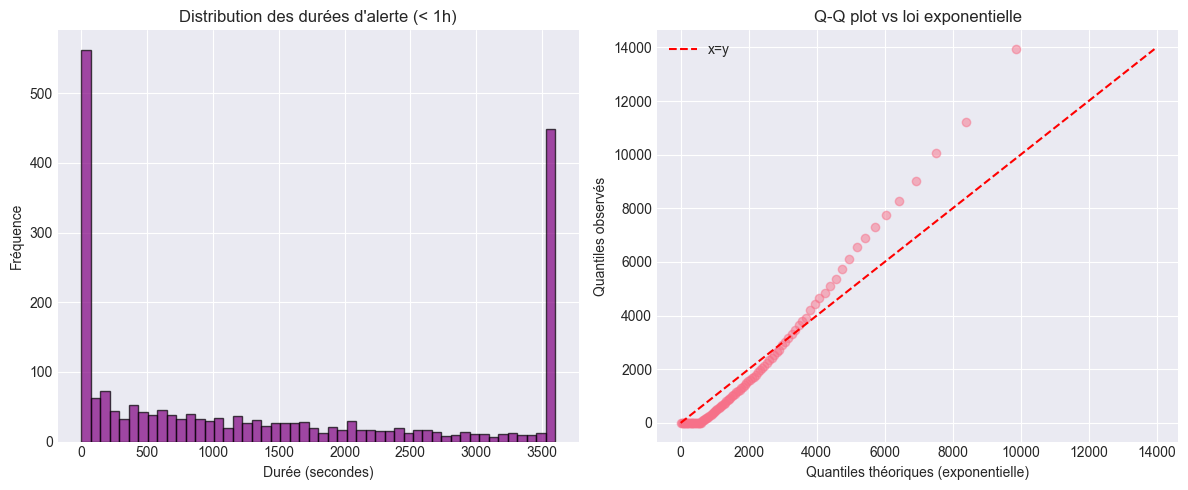


6.4 Simulation de Monte Carlo des durées d'alerte
Paramètre λ estimé: 0.000467 (durée moyenne: 2141.5s)
Probabilité qu'une alerte dure > 5 min: 87.4%
Probabilité qu'une alerte dure > 15 min: 66.1%
Probabilité qu'une alerte dure > 30 min: 43.9%

6.5 Test d'adéquation à la loi exponentielle
Test de Kolmogorov-Smirnov:
  Statistique: 0.2471
  p-value: 0.0000
  → On rejette H0: les durées ne suivent pas une loi exponentielle

[7] SYNTHÈSE DES RÉSULTATS

7.1 Résumé des données:
• 507,071 éclairs analysés sur 7 ans
• 128,992 éclairs nuage-sol (25.4%)
• 56,599 éclairs dans des alertes
• 769 alertes identifiées

7.2 Performances ML (prédiction de fin d'orage):


NameError: name 'best_model_name' is not defined

In [10]:

# ============================================================
# PARTIE 6: PROCESSUS STOCHASTIQUE - CHAÎNE DE MARKOV
# ============================================================

print("\n[6] PROCESSUS STOCHASTIQUE - CHAÎNE DE MARKOV")
print("-" * 50)

# 6.1 Construction de la chaîne de Markov pour les états d'alerte
print("\n6.1 Analyse des transitions d'états...")

# Création des états basés sur l'intensité
df_alertes['intensity_state'] = pd.cut(
    df_alertes['amplitude'].abs(),
    bins=[0, 10, 30, 100, float('inf')],
    labels=['Faible', 'Moyenne', 'Forte', 'Très forte']
)

# États de distance
df_alertes['distance_state'] = pd.cut(
    df_alertes['dist'],
    bins=[0, 5, 10, 20, float('inf')],
    labels=['Proche', 'Moyen', 'Éloigné', 'Très éloigné']
)

# États combinés
df_alertes['combined_state'] = df_alertes['intensity_state'].astype(str) + '-' + df_alertes['distance_state'].astype(str)

# 6.2 Matrice de transition pour chaque alerte
print("\n6.2 Calcul des matrices de transition...")

def compute_transition_matrix(sequence, states):
    """Calcule la matrice de transition pour une séquence"""
    n_states = len(states)
    trans_matrix = np.zeros((n_states, n_states))
    state_to_idx = {state: i for i, state in enumerate(states)}
    
    for i in range(len(sequence)-1):
        current_state = sequence.iloc[i]
        next_state = sequence.iloc[i+1]
        if pd.notna(current_state) and pd.notna(next_state):
            trans_matrix[state_to_idx[current_state], state_to_idx[next_state]] += 1
    
    # Normalisation
    row_sums = trans_matrix.sum(axis=1, keepdims=True)
    trans_matrix = np.divide(trans_matrix, row_sums, where=row_sums>0)
    return trans_matrix

# Matrice de transition globale
states = df_alertes['combined_state'].dropna().unique()
global_trans_matrix = compute_transition_matrix(df_alertes['combined_state'].dropna(), states)

print(f"Matrice de transition ({len(states)} états):")
print(global_trans_matrix.round(3))

# 6.3 Temps d'arrêt - Durée des alertes
print("\n6.3 Analyse des temps d'arrêt (durée des alertes)")

# Récupérer la durée de chaque alerte
alert_durations = df_features[['alert_id', 'duration']].drop_duplicates()

# Distribution des durées
print(f"Statistiques des durées d'alerte (secondes):")
print(f"  Moyenne: {alert_durations['duration'].mean():.1f}")
print(f"  Médiane: {alert_durations['duration'].median():.1f}")
print(f"  Écart-type: {alert_durations['duration'].std():.1f}")
print(f"  Min: {alert_durations['duration'].min():.1f}")
print(f"  Max: {alert_durations['duration'].max():.1f}")

# Visualisation des durées
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(alert_durations['duration'].clip(upper=3600), bins=50, 
            color='purple', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Durée (secondes)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution des durées d\'alerte (< 1h)')

# QQ plot pour vérifier la distribution exponentielle
from scipy import stats
params = stats.expon.fit(alert_durations['duration'])
theoretical_quantiles = stats.expon.ppf(np.linspace(0.01, 0.99, 100), *params)
sample_quantiles = np.percentile(alert_durations['duration'], np.linspace(1, 99, 100))

axes[1].scatter(theoretical_quantiles, sample_quantiles, alpha=0.5)
axes[1].plot([0, sample_quantiles.max()], [0, sample_quantiles.max()], 'r--', label='x=y')
axes[1].set_xlabel('Quantiles théoriques (exponentielle)')
axes[1].set_ylabel('Quantiles observés')
axes[1].set_title('Q-Q plot vs loi exponentielle')
axes[1].legend()

plt.tight_layout()
plt.savefig('alert_durations.png', dpi=150)
plt.show()

# 6.4 Simulation de Monte Carlo des durées d'alerte
print("\n6.4 Simulation de Monte Carlo des durées d'alerte")

# Estimation des paramètres
lambda_exp = 1 / alert_durations['duration'].mean()

# Simulation
n_simulations = 10000
simulated_durations = np.random.exponential(scale=1/lambda_exp, size=n_simulations)

print(f"Paramètre λ estimé: {lambda_exp:.6f} (durée moyenne: {1/lambda_exp:.1f}s)")
print(f"Probabilité qu'une alerte dure > 5 min: {np.mean(simulated_durations > 300)*100:.1f}%")
print(f"Probabilité qu'une alerte dure > 15 min: {np.mean(simulated_durations > 900)*100:.1f}%")
print(f"Probabilité qu'une alerte dure > 30 min: {np.mean(simulated_durations > 1800)*100:.1f}%")

# 6.5 Test d'hypothèse - Loi exponentielle
print("\n6.5 Test d'adéquation à la loi exponentielle")
ks_statistic, ks_pvalue = stats.kstest(alert_durations['duration'], 'expon', args=params)
print(f"Test de Kolmogorov-Smirnov:")
print(f"  Statistique: {ks_statistic:.4f}")
print(f"  p-value: {ks_pvalue:.4f}")
if ks_pvalue > 0.05:
    print("  → On ne rejette pas H0: les durées suivent une loi exponentielle")
else:
    print("  → On rejette H0: les durées ne suivent pas une loi exponentielle")

# ============================================================
# PARTIE 7: SYNTHÈSE ET CONCLUSIONS
# ============================================================

print("\n[7] SYNTHÈSE DES RÉSULTATS")
print("="*80)

print("\n7.1 Résumé des données:")
print(f"• {len(df):,} éclairs analysés sur {df['date'].dt.year.nunique()} ans")
print(f"• {icloud_dist.get(False, 0):,} éclairs nuage-sol ({icloud_dist.get(False, 0)/len(df)*100:.1f}%)")
print(f"• {len(df_alertes):,} éclairs dans des alertes")
print(f"• {df_alertes['airport_alert_id'].nunique():,} alertes identifiées")

print("\n7.2 Performances ML (prédiction de fin d'orage):")
for name, res in results.items():
    print(f"• {name}: F1={res['f1']:.3f}, AUC={res['auc']:.3f}")

print(f"\nMeilleur modèle: {best_model_name}")

print("\n7.3 Caractéristiques des processus stochastiques:")
print(f"• Durée moyenne d'alerte: {alert_durations['duration'].mean():.1f} secondes")
print(f"• Taux d'arrivée λ: {lambda_exp:.6f} événements/seconde")
print(f"• Probabilité de transition entre états: modélisée par chaîne de Markov")

print("\n7.4 Facteurs prédictifs les plus importants:")
top_features = feature_importance.head(5)['feature'].tolist() if 'feature_importance' in locals() else ['N/A']
for i, feat in enumerate(top_features, 1):
    print(f"• {i}. {feat}")

print("\n" + "="*80)
print("ANALYSE TERMINÉE - RAPPORT COMPLET")
print("="*80)

# Sauvegarde des résultats
print("\nSauvegarde des résultats...")

# Sauvegarder les prédictions
df_features['predicted_fin_orage'] = best_model.predict(X)
df_features[['alert_id', 'target', 'predicted_fin_orage'] + feature_cols].to_csv('predictions_fin_orage.csv', index=False)
print("✓ Prédictions sauvegardées dans 'predictions_fin_orage.csv'")

# Sauvegarder la matrice de transition
transition_df = pd.DataFrame(global_trans_matrix, 
                            index=states[:global_trans_matrix.shape[0]], 
                            columns=states[:global_trans_matrix.shape[1]])
transition_df.to_csv('transition_matrix.csv')
print("✓ Matrice de transition sauvegardée dans 'transition_matrix.csv'")

print("\n✅ Analyse complète terminée avec succès!")

1. CHARGEMENT DES DONNÉES
Dimensions brutes : (507071, 13)

Colonnes : ['lightning_id', 'lightning_airport_id', 'date', 'lon', 'lat', 'amplitude', 'maxis', 'icloud', 'dist', 'azimuth', 'airport', 'airport_alert_id', 'is_last_lightning_cloud_ground']

Types :
lightning_id                        int64
lightning_airport_id                int64
date                               object
lon                               float64
lat                               float64
amplitude                         float64
maxis                             float64
icloud                               bool
dist                              float64
azimuth                           float64
airport                            object
airport_alert_id                  float64
is_last_lightning_cloud_ground     object
dtype: object

NaN par colonne :
lightning_id                           0
lightning_airport_id                   0
date                                   0
lon                                    

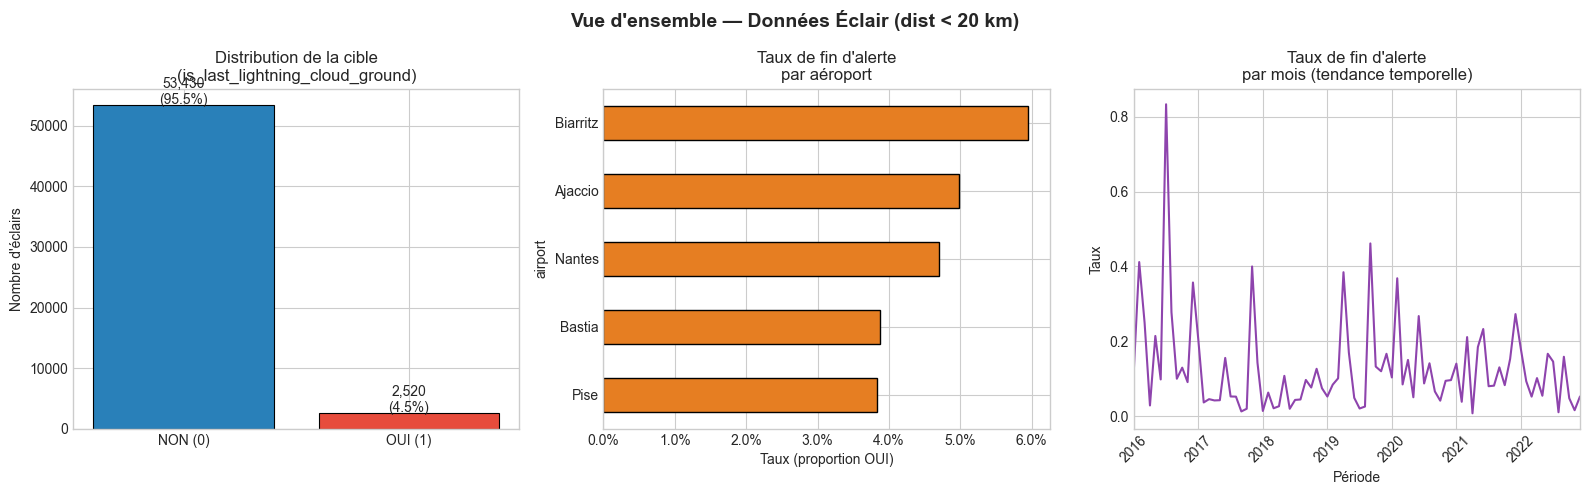

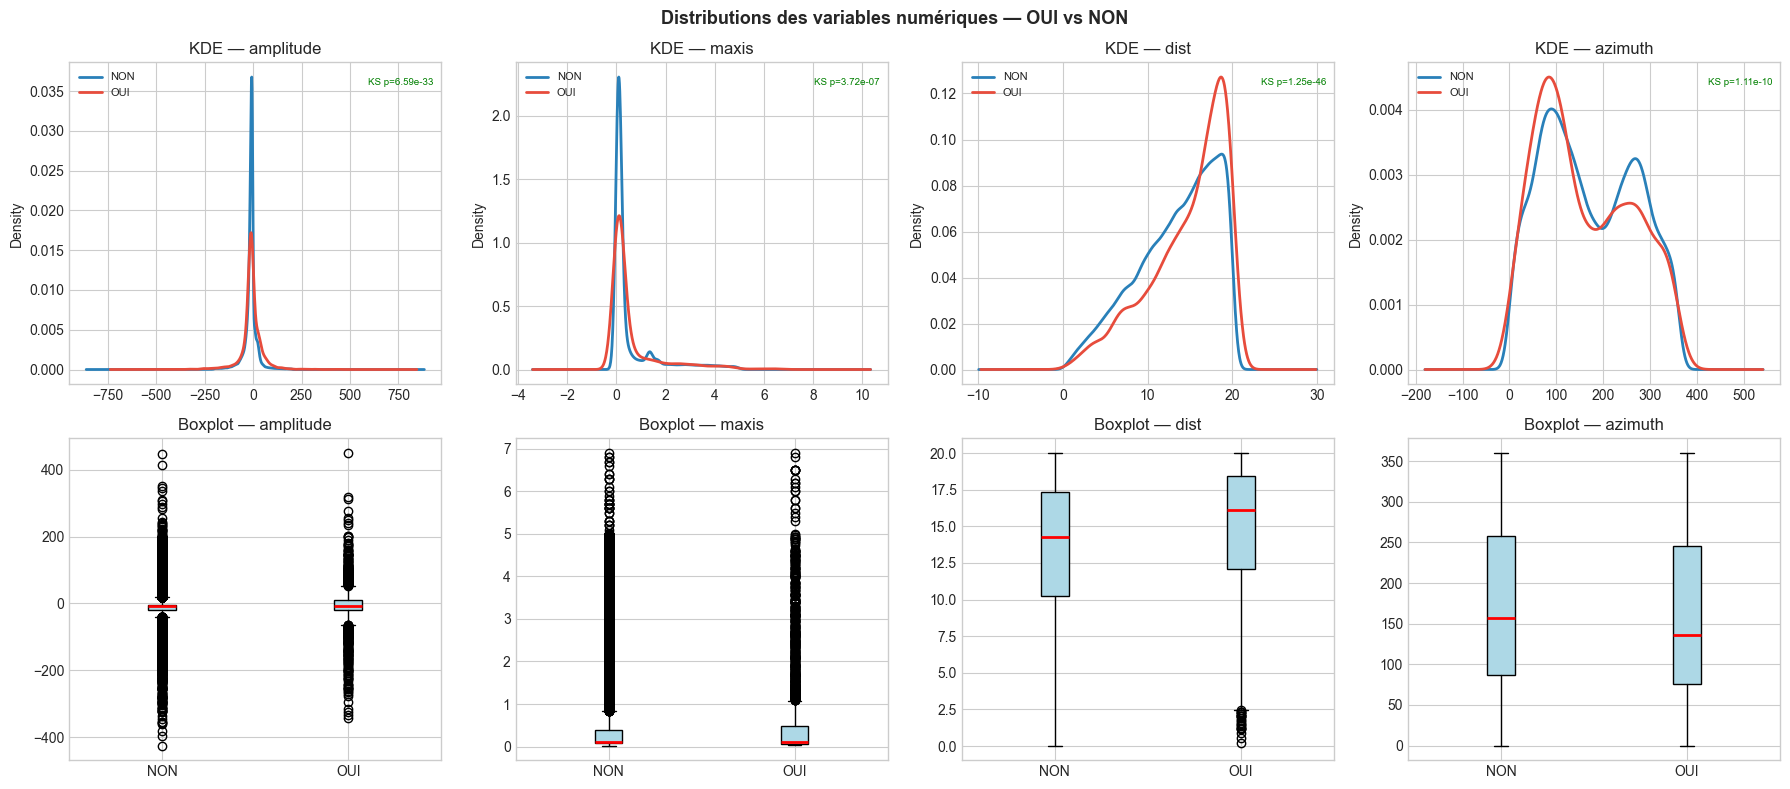

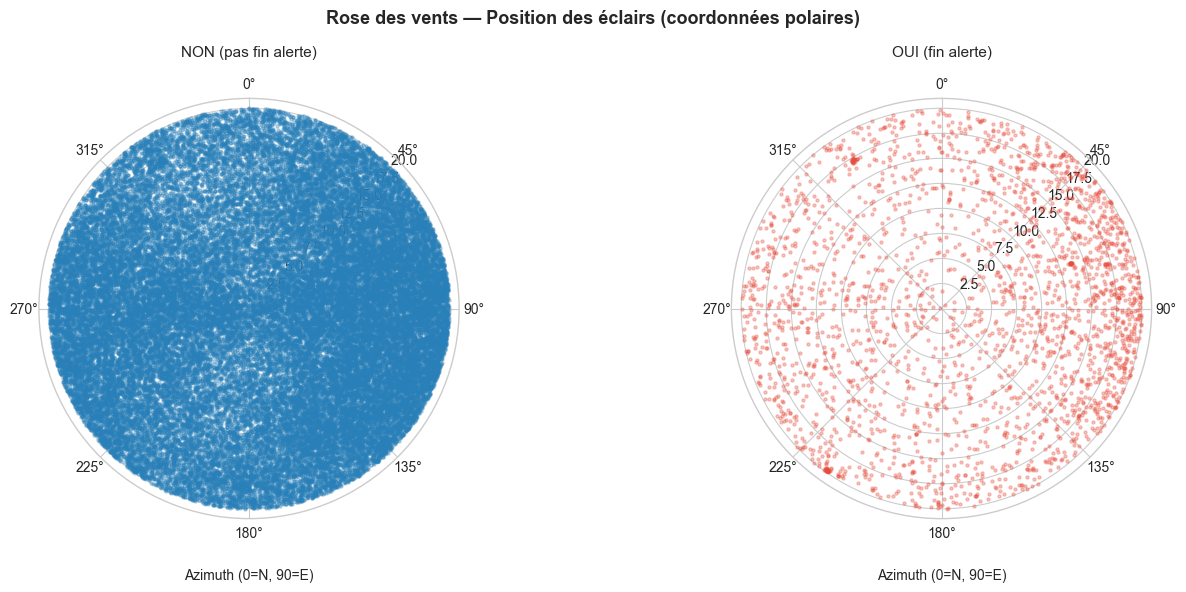

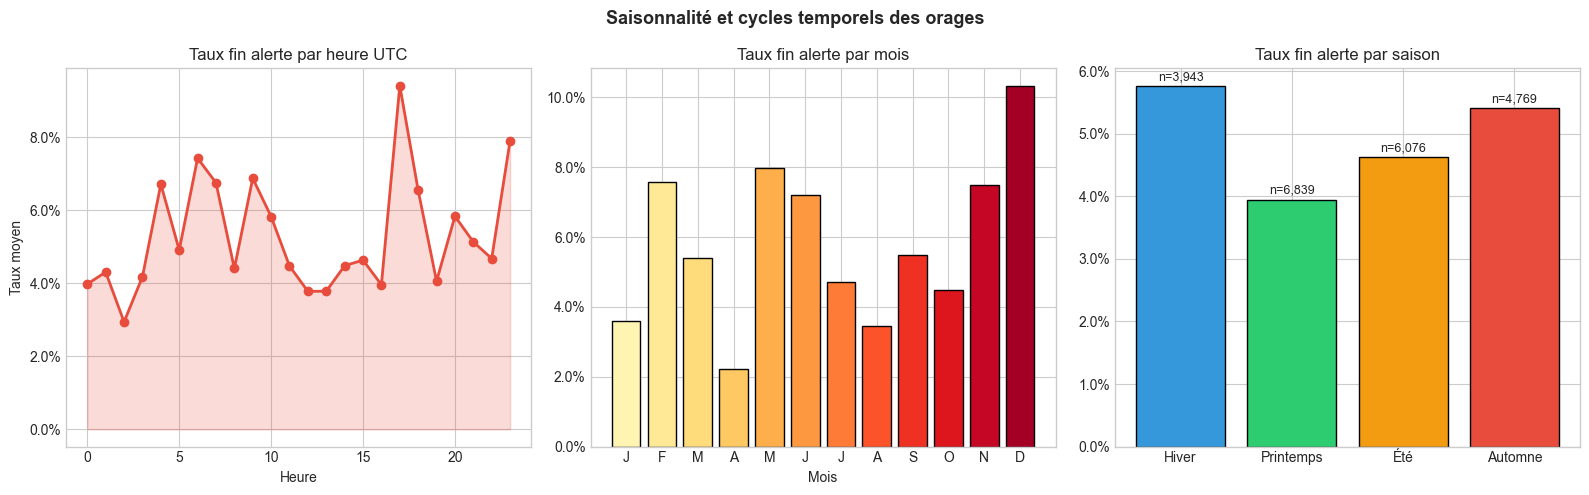


3. FEATURE ENGINEERING
Features construites : 20
X shape : (55950, 20) — Taux positif : 4.50%

4. FEATURE SELECTION

── Top 15 features (rang agrégé) ──
          feature       MI  RF_importance  Pearson_abs  mean_rank
 dist_x_amplitude 0.004638       0.099734     0.081127   3.333333
        amplitude 0.005423       0.103685     0.021355   3.666667
    abs_amplitude 0.004883       0.068430     0.069280   4.333333
log_abs_amplitude 0.004664       0.064569     0.072506   4.666667
             dist 0.002492       0.102727     0.058669   6.333333
        dayofyear 0.012433       0.045590     0.017428   6.666667
            x_pos 0.002783       0.064238     0.028929   7.333333
   amplitude_sign 0.002932       0.025633     0.060244   8.333333
            maxis 0.002571       0.092766     0.008004   9.666667
  is_cloud_ground 0.010940       0.000000          NaN  11.000000
          azimuth 0.001311       0.044600     0.021242  11.000000
      airport_enc 0.002723       0.037250     0.013425

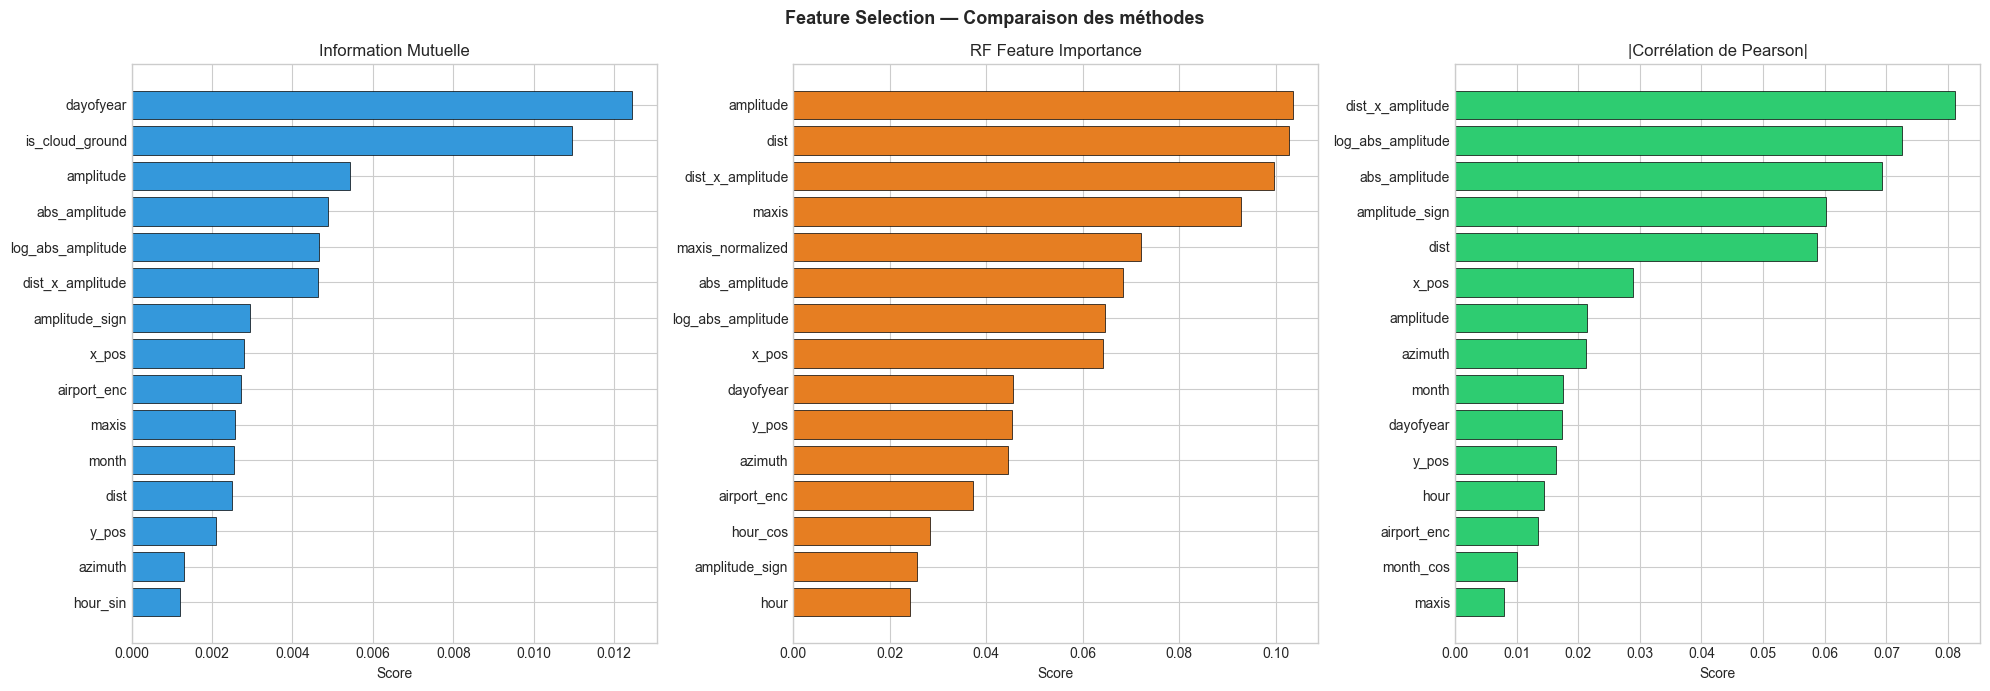

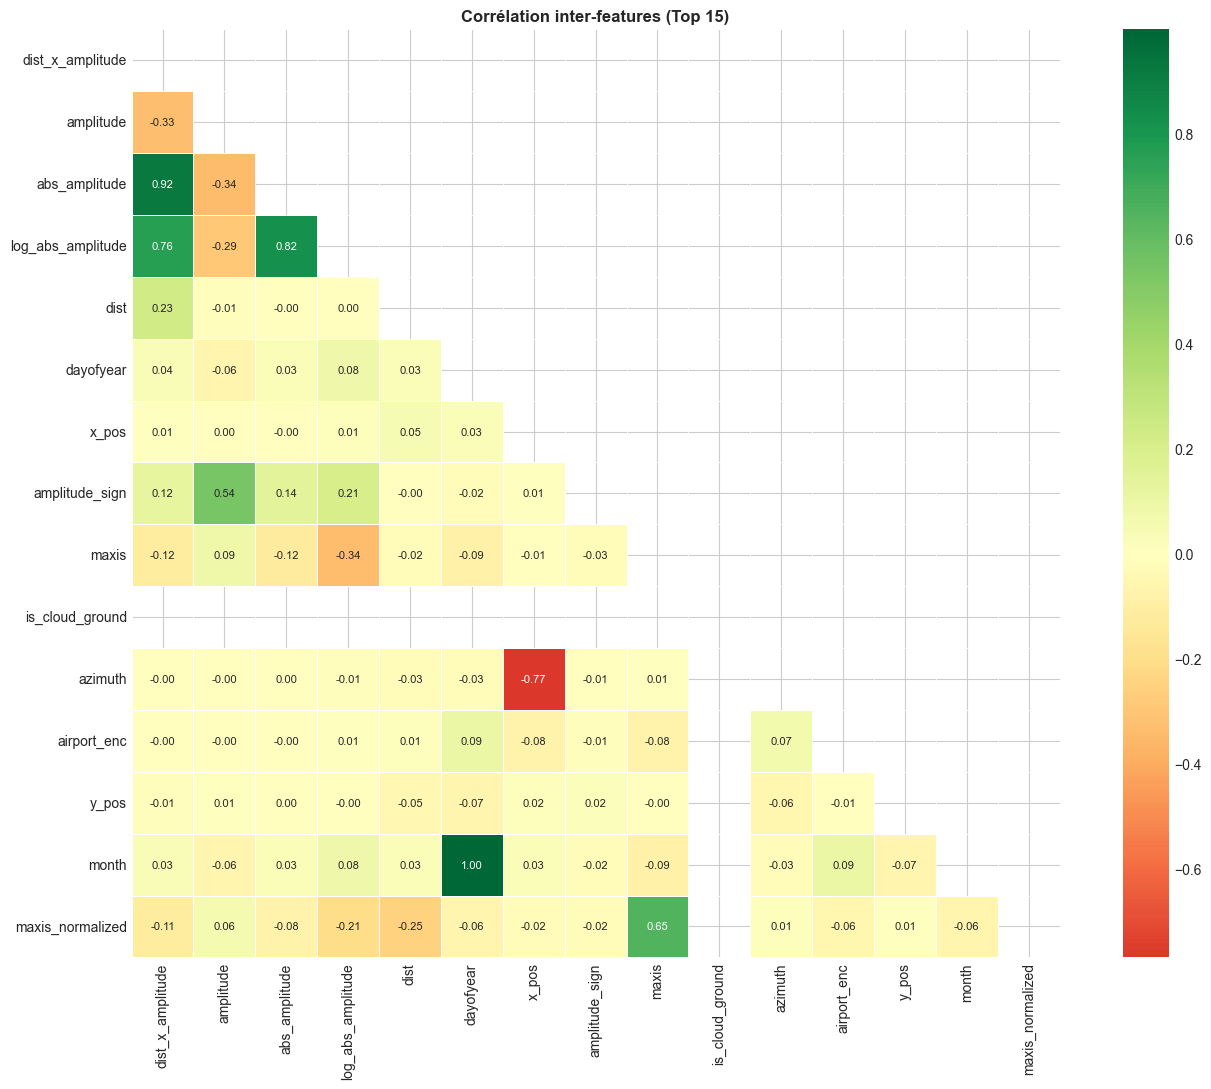


Features sélectionnées (12) : ['dist_x_amplitude', 'amplitude', 'abs_amplitude', 'log_abs_amplitude', 'dist', 'dayofyear', 'x_pos', 'amplitude_sign', 'maxis', 'is_cloud_ground', 'azimuth', 'airport_enc']

5. MACHINE LEARNING — CLASSIFICATION (classe déséquilibrée)
  Logistic Regression       | ROC-AUC=0.6478±0.0114 | AP=0.0828±0.0039
  Random Forest             | ROC-AUC=0.6958±0.0082 | AP=0.1086±0.0069
  Gradient Boosting         | ROC-AUC=0.7328±0.0101 | AP=0.1341±0.0040
  XGBoost                   | ROC-AUC=0.7302±0.0101 | AP=0.1325±0.0100

→ Meilleur modèle : Gradient Boosting


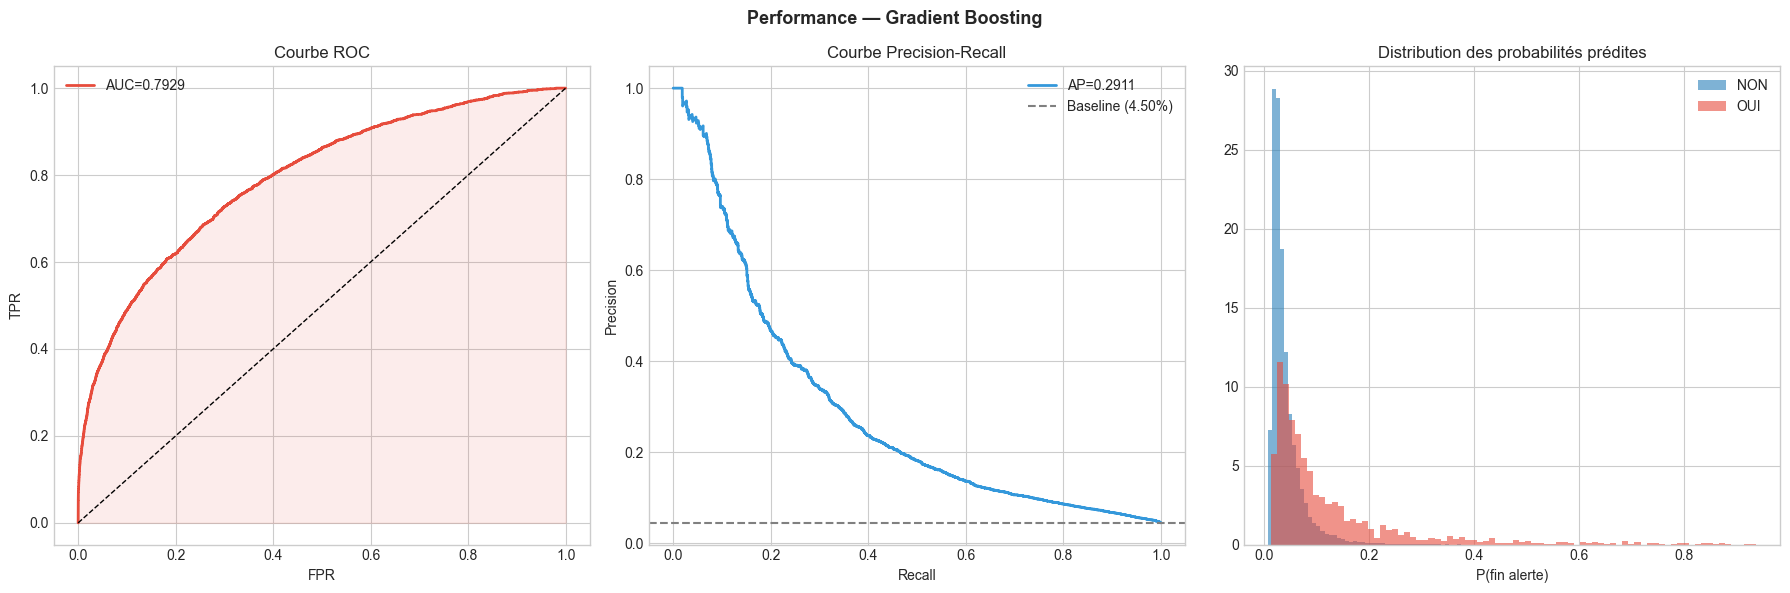


Seuil optimal F1 : 0.123 (F1=0.3216)

Classification Report :
              precision    recall  f1-score   support

         NON       0.97      0.97      0.97     53430
         OUI       0.33      0.31      0.32      2520

    accuracy                           0.94     55950
   macro avg       0.65      0.64      0.65     55950
weighted avg       0.94      0.94      0.94     55950



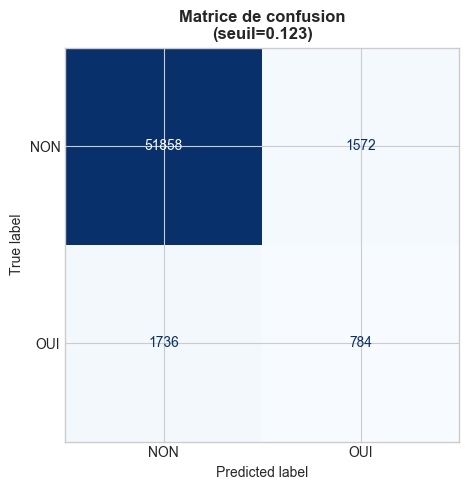


Calcul SHAP values...


ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- hour
- hour_cos
- hour_sin
- maxis_normalized
- month
- ...


In [11]:
"""
=============================================================================
THUNDERSTORM ANALYSIS PIPELINE — Data Scientist Spécialiste Orages
=============================================================================
Objectif : Prédire is_last_lightning_cloud_ground (fin d'alerte = 4% positif)
Pipeline  : EDA rigoureuse → Feature Engineering → Feature Selection →
            ML (classification déséquilibrée) → Processus Stochastique /
            Chaîne de Markov sur les temps d'arrêt
=============================================================================
"""

# ─────────────────────────────────────────────────────────────────────────────
# 0. IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, ks_2samp
import matplotlib.ticker as mtick

# ML
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_classif, SelectKBest, f_classif

# XGBoost (si disponible)
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost non disponible — on continue sans.")

# SHAP (si disponible)
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("SHAP non disponible — on continue sans.")

# imbalanced-learn
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    HAS_IMBLEARN = True
except ImportError:
    HAS_IMBLEARN = False
    print("imbalanced-learn non disponible — on continue sans SMOTE.")

plt.style.use("seaborn-v0_8-whitegrid")
PALETTE = {"OUI": "#e74c3c", "NON": "#2980b9"}
FIGDIR = "figures/"
import os
os.makedirs(FIGDIR, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# 1. CHARGEMENT & NETTOYAGE
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("1. CHARGEMENT DES DONNÉES")
print("=" * 70)

df = pd.read_csv('data_train_databattle2026\\segment_alerts_all_airports_train.csv')

print(f"Dimensions brutes : {df.shape}")
print(f"\nColonnes : {list(df.columns)}")
print(f"\nTypes :\n{df.dtypes}")
print(f"\nNaN par colonne :\n{df.isna().sum()}")

# ── Parsing date
df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")

# ── Normalisation booléens français
for col in ["icloud", "is_last_lightning_cloud_ground"]:
    if col in df.columns:
        df[col] = df[col].map(
            {"VRAI": True, "FAUX": False, True: True, False: False,
             "True": True, "False": False, 1: True, 0: False}
        )

# ── Filtrer Pise 2016 (enregistrement intra-nuage défaillant)
mask_pise_2016 = (df["airport"] == "Pise") & (df["date"].dt.year == 2016)
df_clean = df[~mask_pise_2016].copy()
print(f"\nAprès retrait Pise 2016 : {df_clean.shape}")

# ── Sous-ensemble étiqueté (is_last_lightning_cloud_ground renseigné)
df_labeled = df_clean[df_clean["is_last_lightning_cloud_ground"].notna()].copy()
df_labeled["target"] = df_labeled["is_last_lightning_cloud_ground"].astype(int)
print(f"\nLignes étiquetées (dist < 20 km) : {len(df_labeled):,}")
print(f"Taux positif (fin alerte) : {df_labeled['target'].mean():.2%}")

# ─────────────────────────────────────────────────────────────────────────────
# 2. EDA — VISUALISATIONS RIGOUREUSES
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("2. EDA — ANALYSE EXPLORATOIRE RIGOUREUSE")
print("=" * 70)

# ── 2.1 Distribution globale de la cible
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Vue d'ensemble — Données Éclair (dist < 20 km)", fontsize=14, fontweight="bold")

counts = df_labeled["target"].value_counts()
axes[0].bar(["NON (0)", "OUI (1)"], counts.values,
            color=[PALETTE["NON"], PALETTE["OUI"]], edgecolor="black", linewidth=0.8)
axes[0].set_title("Distribution de la cible\n(is_last_lightning_cloud_ground)")
axes[0].set_ylabel("Nombre d'éclairs")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f"{v:,}\n({v/counts.sum():.1%})", ha="center", fontsize=10)

# Répartition par aéroport
airport_target = df_labeled.groupby("airport")["target"].agg(["sum", "count"])
airport_target["rate"] = airport_target["sum"] / airport_target["count"]
airport_target["rate"].sort_values().plot(kind="barh", ax=axes[1],
    color="#e67e22", edgecolor="black")
axes[1].set_title("Taux de fin d'alerte\npar aéroport")
axes[1].set_xlabel("Taux (proportion OUI)")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Distribution temporelle (par année-mois)
df_labeled["ym"] = df_labeled["date"].dt.to_period("M")
monthly = df_labeled.groupby("ym")["target"].agg(["sum", "count"])
monthly["rate"] = monthly["sum"] / monthly["count"]
monthly["rate"].plot(ax=axes[2], color="#8e44ad", linewidth=1.5)
axes[2].set_title("Taux de fin d'alerte\npar mois (tendance temporelle)")
axes[2].set_xlabel("Période")
axes[2].set_ylabel("Taux")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{FIGDIR}01_overview.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 2.2 Variables numériques — distributions par classe
num_cols = ["amplitude", "maxis", "dist", "azimuth"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Distributions des variables numériques — OUI vs NON", fontsize=13, fontweight="bold")

for i, col in enumerate(num_cols):
    d0 = df_labeled[df_labeled["target"] == 0][col].dropna()
    d1 = df_labeled[df_labeled["target"] == 1][col].dropna()

    # KDE
    ax = axes[0, i]
    d0.plot.kde(ax=ax, color=PALETTE["NON"], label="NON", linewidth=2)
    d1.plot.kde(ax=ax, color=PALETTE["OUI"], label="OUI", linewidth=2)
    ax.set_title(f"KDE — {col}")
    ax.legend(fontsize=8)

    # Box plot
    ax2 = axes[1, i]
    ax2.boxplot([d0, d1], labels=["NON", "OUI"],
                patch_artist=True,
                boxprops=dict(facecolor="lightblue"),
                medianprops=dict(color="red", linewidth=2))
    ax2.set_title(f"Boxplot — {col}")

    # KS test
    ks_stat, ks_p = ks_2samp(d0, d1)
    ax.text(0.98, 0.95, f"KS p={ks_p:.2e}", transform=ax.transAxes,
            ha="right", va="top", fontsize=7,
            color="green" if ks_p < 0.05 else "gray")

plt.tight_layout()
plt.savefig(f"{FIGDIR}02_numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 2.3 Carte de chaleur azimuth × dist (Rose des vents)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw=dict(projection="polar"))
fig.suptitle("Rose des vents — Position des éclairs (coordonnées polaires)", fontsize=13, fontweight="bold")

for ax, (label, sub) in zip(axes, [("NON (pas fin alerte)", df_labeled[df_labeled["target"]==0]),
                                     ("OUI (fin alerte)", df_labeled[df_labeled["target"]==1])]):
    theta = np.radians(sub["azimuth"].dropna())
    r = sub["dist"].dropna()
    min_len = min(len(theta), len(r))
    ax.scatter(theta[:min_len], r[:min_len], alpha=0.3, s=5,
               c=PALETTE["OUI"] if "OUI" in label else PALETTE["NON"])
    ax.set_title(label, pad=15, fontsize=11)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_rlabel_position(45)
    ax.set_xlabel("Azimuth (0=N, 90=E)", labelpad=20)

plt.tight_layout()
plt.savefig(f"{FIGDIR}03_polar_rose.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 2.4 Analyse temporelle intra-journalière & saisonnalité
df_labeled["hour"] = df_labeled["date"].dt.hour
df_labeled["month"] = df_labeled["date"].dt.month
df_labeled["season"] = df_labeled["month"].map(
    {12: "Hiver", 1: "Hiver", 2: "Hiver",
     3: "Printemps", 4: "Printemps", 5: "Printemps",
     6: "Été", 7: "Été", 8: "Été",
     9: "Automne", 10: "Automne", 11: "Automne"})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Saisonnalité et cycles temporels des orages", fontsize=13, fontweight="bold")

# Heure
hourly = df_labeled.groupby("hour")["target"].mean()
axes[0].plot(hourly.index, hourly.values, "o-", color="#e74c3c", linewidth=2)
axes[0].fill_between(hourly.index, hourly.values, alpha=0.2, color="#e74c3c")
axes[0].set_title("Taux fin alerte par heure UTC")
axes[0].set_xlabel("Heure")
axes[0].set_ylabel("Taux moyen")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Mois
monthly_rate = df_labeled.groupby("month")["target"].mean()
axes[1].bar(monthly_rate.index, monthly_rate.values,
            color=sns.color_palette("YlOrRd", 12), edgecolor="black")
axes[1].set_title("Taux fin alerte par mois")
axes[1].set_xlabel("Mois")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Saison
season_order = ["Hiver", "Printemps", "Été", "Automne"]
season_data = df_labeled.groupby("season")["target"].agg(["mean", "count"])
season_data = season_data.reindex(season_order)
bars = axes[2].bar(season_data.index, season_data["mean"],
                   color=["#3498db", "#2ecc71", "#f39c12", "#e74c3c"],
                   edgecolor="black")
axes[2].set_title("Taux fin alerte par saison")
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
for bar, (_, row) in zip(bars, season_data.iterrows()):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f"n={int(row['count']):,}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(f"{FIGDIR}04_temporal_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 3. FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("3. FEATURE ENGINEERING")
print("=" * 70)

def build_features(df_in):
    d = df_in.copy()

    # ── Temporel
    d["hour"]         = d["date"].dt.hour
    d["minute"]       = d["date"].dt.minute
    d["month"]        = d["date"].dt.month
    d["dayofyear"]    = d["date"].dt.dayofyear
    d["hour_sin"]     = np.sin(2 * np.pi * d["hour"] / 24)
    d["hour_cos"]     = np.cos(2 * np.pi * d["hour"] / 24)
    d["month_sin"]    = np.sin(2 * np.pi * d["month"] / 12)
    d["month_cos"]    = np.cos(2 * np.pi * d["month"] / 12)

    # ── Géométrique (polaire → cartésien)
    az_rad = np.radians(d["azimuth"])
    d["x_pos"] = d["dist"] * np.sin(az_rad)
    d["y_pos"] = d["dist"] * np.cos(az_rad)

    # ── Intensité absolue
    d["abs_amplitude"] = d["amplitude"].abs()
    d["log_abs_amplitude"] = np.log1p(d["abs_amplitude"])
    d["amplitude_sign"] = (d["amplitude"] > 0).astype(int)

    # ── Quadrant géographique
    d["quadrant"] = pd.cut(d["azimuth"] % 360,
                            bins=[0, 90, 180, 270, 360],
                            labels=["N-E", "S-E", "S-O", "N-O"],
                            right=False)

    # ── Nature de l'éclair
    d["is_cloud_ground"] = (~d["icloud"].fillna(False)).astype(int)

    # ── Zones de distance (bandes concentriques)
    d["dist_band"] = pd.cut(d["dist"], bins=[0, 5, 10, 15, 20],
                             labels=["0-5km", "5-10km", "10-15km", "15-20km"])

    # ── Interaction dist × amplitude
    d["dist_x_amplitude"] = d["dist"] * d["abs_amplitude"]

    # ── Erreur de localisation normalisée
    d["maxis_normalized"] = d["maxis"] / (d["dist"] + 1e-3)

    return d

df_feat = build_features(df_labeled)

feature_cols = [
    "amplitude", "abs_amplitude", "log_abs_amplitude", "amplitude_sign",
    "maxis", "maxis_normalized",
    "dist", "azimuth", "x_pos", "y_pos",
    "hour", "hour_sin", "hour_cos",
    "month", "month_sin", "month_cos",
    "dayofyear",
    "is_cloud_ground",
    "dist_x_amplitude",
]
# Encodage aéroport
le_airport = LabelEncoder()
df_feat["airport_enc"] = le_airport.fit_transform(df_feat["airport"].astype(str))
feature_cols.append("airport_enc")

X = df_feat[feature_cols].fillna(0)
y = df_feat["target"]

print(f"Features construites : {len(feature_cols)}")
print(f"X shape : {X.shape} — Taux positif : {y.mean():.2%}")

# ─────────────────────────────────────────────────────────────────────────────
# 4. FEATURE SELECTION RIGOUREUSE
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("4. FEATURE SELECTION")
print("=" * 70)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── 4.1 Information Mutuelle
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({"feature": feature_cols, "MI": mi_scores}).sort_values("MI", ascending=False)

# ── 4.2 Random Forest importance
rf_sel = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                 random_state=42, n_jobs=-1, max_depth=8)
rf_sel.fit(X, y)
rf_imp = pd.DataFrame({
    "feature": feature_cols,
    "RF_importance": rf_sel.feature_importances_
}).sort_values("RF_importance", ascending=False)

# ── 4.3 Corrélation de Pearson (avec la cible)
pearson_corr = X.corrwith(y.astype(float)).abs().sort_values(ascending=False)
pearson_df = pd.DataFrame({"feature": pearson_corr.index, "Pearson_abs": pearson_corr.values})

# ── Consolidation
fs_merged = mi_df.merge(rf_imp, on="feature").merge(pearson_df, on="feature")
# Rang agrégé
for col in ["MI", "RF_importance", "Pearson_abs"]:
    fs_merged[f"rank_{col}"] = fs_merged[col].rank(ascending=False)
fs_merged["mean_rank"] = fs_merged[["rank_MI", "rank_RF_importance", "rank_Pearson_abs"]].mean(axis=1)
fs_merged = fs_merged.sort_values("mean_rank")

print("\n── Top 15 features (rang agrégé) ──")
print(fs_merged[["feature", "MI", "RF_importance", "Pearson_abs", "mean_rank"]].head(15).to_string(index=False))

# ── Visualisation feature selection
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Feature Selection — Comparaison des méthodes", fontsize=13, fontweight="bold")

for ax, (col, label, color) in zip(axes, [
    ("MI", "Information Mutuelle", "#3498db"),
    ("RF_importance", "RF Feature Importance", "#e67e22"),
    ("Pearson_abs", "|Corrélation de Pearson|", "#2ecc71")
]):
    top = fs_merged.nlargest(15, col)[["feature", col]].sort_values(col)
    ax.barh(top["feature"], top[col], color=color, edgecolor="black", linewidth=0.5)
    ax.set_title(label)
    ax.set_xlabel("Score")

plt.tight_layout()
plt.savefig(f"{FIGDIR}05_feature_selection.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Corrélation inter-features (multicolinéarité)
fig, ax = plt.subplots(figsize=(14, 11))
corr_matrix = X[fs_merged["feature"].head(15).tolist()].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=ax, linewidths=0.5, square=True,
            annot_kws={"size": 8})
ax.set_title("Corrélation inter-features (Top 15)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGDIR}06_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Sélection finale
TOP_N = 12
selected_features = fs_merged["feature"].head(TOP_N).tolist()
print(f"\nFeatures sélectionnées ({TOP_N}) : {selected_features}")
X_sel = X[selected_features]

# ─────────────────────────────────────────────────────────────────────────────
# 5. MACHINE LEARNING — CLASSIFICATION DÉSÉQUILIBRÉE
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("5. MACHINE LEARNING — CLASSIFICATION (classe déséquilibrée)")
print("=" * 70)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, C=0.1, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", max_depth=10,
        min_samples_leaf=10, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42),
}

if HAS_XGB:
    scale_pos = (y == 0).sum() / (y == 1).sum()
    models["XGBoost"] = xgb.XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        scale_pos_weight=scale_pos, subsample=0.8, colsample_bytree=0.8,
        eval_metric="aucpr", random_state=42, n_jobs=-1, verbosity=0)

results = {}
for name, model in models.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", model)])
    auc_scores = cross_val_score(pipe, X_sel, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    ap_scores  = cross_val_score(pipe, X_sel, y, cv=cv,
                                  scoring="average_precision", n_jobs=-1)
    results[name] = {
        "ROC-AUC": auc_scores.mean(),
        "ROC-AUC_std": auc_scores.std(),
        "AP": ap_scores.mean(),
        "AP_std": ap_scores.std(),
    }
    print(f"  {name:25s} | ROC-AUC={auc_scores.mean():.4f}±{auc_scores.std():.4f}"
          f" | AP={ap_scores.mean():.4f}±{ap_scores.std():.4f}")

# ── Entraînement du meilleur modèle (RF ou XGB)
best_name = max(results, key=lambda k: results[k]["AP"])
print(f"\n→ Meilleur modèle : {best_name}")

best_model_raw = models[best_name]
best_pipe = Pipeline([("scaler", StandardScaler()), ("clf", best_model_raw)])
best_pipe.fit(X_sel, y)

# ── Courbes ROC et PR sur train (pour visualisation — attention overfitting)
y_proba = best_pipe.predict_proba(X_sel)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f"Performance — {best_name}", fontsize=13, fontweight="bold")

# ROC
fpr, tpr, _ = roc_curve(y, y_proba)
auc_val = roc_auc_score(y, y_proba)
axes[0].plot(fpr, tpr, color="#e74c3c", lw=2, label=f"AUC={auc_val:.4f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("Courbe ROC")
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].legend()
axes[0].fill_between(fpr, tpr, alpha=0.1, color="#e74c3c")

# PR
prec, rec, thresholds = precision_recall_curve(y, y_proba)
ap_val = average_precision_score(y, y_proba)
axes[1].plot(rec, prec, color="#3498db", lw=2, label=f"AP={ap_val:.4f}")
axes[1].axhline(y.mean(), color="gray", linestyle="--", label=f"Baseline ({y.mean():.2%})")
axes[1].set_title("Courbe Precision-Recall")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

# Score calibration / distribution des proba
axes[2].hist(y_proba[y == 0], bins=80, color=PALETTE["NON"], alpha=0.6, label="NON", density=True)
axes[2].hist(y_proba[y == 1], bins=80, color=PALETTE["OUI"], alpha=0.6, label="OUI", density=True)
axes[2].set_title("Distribution des probabilités prédites")
axes[2].set_xlabel("P(fin alerte)")
axes[2].legend()

plt.tight_layout()
plt.savefig(f"{FIGDIR}07_model_performance.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Matrice de confusion (seuil optimisé F1)
from sklearn.metrics import f1_score
thresholds_f1 = np.linspace(0.01, 0.99, 200)
f1_vals = [f1_score(y, (y_proba >= t).astype(int)) for t in thresholds_f1]
best_thresh = thresholds_f1[np.argmax(f1_vals)]
print(f"\nSeuil optimal F1 : {best_thresh:.3f} (F1={max(f1_vals):.4f})")

y_pred_opt = (y_proba >= best_thresh).astype(int)
print("\nClassification Report :")
print(classification_report(y, y_pred_opt, target_names=["NON", "OUI"]))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y, y_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NON", "OUI"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Matrice de confusion\n(seuil={best_thresh:.3f})", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGDIR}08_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# ── SHAP (si disponible) pour le meilleur modèle
if HAS_SHAP and hasattr(best_pipe["clf"], "feature_importances_"):
    print("\nCalcul SHAP values...")
    X_sample = X_sel.sample(min(2000, len(X_sel)), random_state=42)
    explainer = shap.TreeExplainer(best_pipe["clf"])
    shap_values = explainer.shap_values(scaler.transform(X_sample) if hasattr(best_pipe, "named_steps") else X_sample)

    fig, ax = plt.subplots(figsize=(10, 7))
    if isinstance(shap_values, list):
        shap.summary_plot(shap_values[1], X_sample, feature_names=selected_features,
                          show=False, plot_type="dot")
    else:
        shap.summary_plot(shap_values, X_sample, feature_names=selected_features,
                          show=False, plot_type="dot")
    plt.title("SHAP Summary Plot — Fin d'alerte", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{FIGDIR}09_shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 6. PROCESSUS STOCHASTIQUE — TEMPS D'ARRÊT & CHAÎNE DE MARKOV
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("6. PROCESSUS STOCHASTIQUE — TEMPS D'ARRÊT & CHAÎNE DE MARKOV")
print("=" * 70)

"""
Modélisation stochastique d'un orage :
Chaque alerte = séquence d'éclairs jusqu'à is_last_lightning_cloud_ground = OUI
On modélise :
  (a) Distribution des temps inter-éclairs (processus de renouvellement)
  (b) Durée totale d'une alerte (temps d'arrêt = hitting time)
  (c) Chaîne de Markov : états = zones de distance {0-5, 5-10, 10-15, 15-20}
      Transitions entre éclairs successifs dans une même alerte
"""

# ── 6.1 Reconstruction des alertes
# On utilise airport_alert_id pour identifier les séquences
df_alerts = df_clean[df_clean["airport_alert_id"].notna()].copy()
df_alerts["date"] = pd.to_datetime(df_alerts["date"], dayfirst=True, errors="coerce")
df_alerts = df_alerts.sort_values(["airport", "airport_alert_id", "date"])

print(f"Éclairs dans des alertes : {len(df_alerts):,}")
print(f"Alertes uniques : {df_alerts.groupby(['airport', 'airport_alert_id']).ngroups:,}")

# ── Temps inter-éclairs (inter-arrival times)
df_alerts["inter_eclair_s"] = (
    df_alerts.groupby(["airport", "airport_alert_id"])["date"]
    .diff().dt.total_seconds()
)

inter_times = df_alerts["inter_eclair_s"].dropna()
inter_times = inter_times[(inter_times > 0) & (inter_times < 3600)]  # sanity

print(f"\nTemps inter-éclairs (secondes) :")
print(f"  Médiane : {inter_times.median():.1f}s | "
      f"Moyenne : {inter_times.mean():.1f}s | "
      f"P95 : {inter_times.quantile(0.95):.1f}s")

# Fit exponentielle (processus de Poisson)
lambda_hat = 1 / inter_times.mean()
print(f"\nFit loi exponentielle : λ = {lambda_hat:.4f} éclairs/s "
      f"({lambda_hat*60:.2f} éclairs/min)")

# ── Durée totale d'une alerte
alert_durations = df_alerts.groupby(["airport", "airport_alert_id"]).agg(
    duree_s=("date", lambda x: (x.max() - x.min()).total_seconds()),
    nb_eclairs=("lightning_id", "count"),
    dist_min=("dist", "min"),
    dist_max=("dist", "max"),
).reset_index()
alert_durations = alert_durations[alert_durations["duree_s"] > 0]

print(f"\nDurée des alertes :")
print(f"  Médiane : {alert_durations['duree_s'].median()/60:.1f} min | "
      f"Moyenne : {alert_durations['duree_s'].mean()/60:.1f} min | "
      f"P95 : {alert_durations['duree_s'].quantile(0.95)/60:.1f} min")
print(f"\nNombre d'éclairs par alerte :")
print(f"  Médiane : {alert_durations['nb_eclairs'].median():.0f} | "
      f"Moyenne : {alert_durations['nb_eclairs'].mean():.1f} | "
      f"P95 : {alert_durations['nb_eclairs'].quantile(0.95):.0f}")

# ── 6.2 Visualisation processus stochastique
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, figure=fig)
fig.suptitle("Processus Stochastique — Analyse des Temps d'Arrêt (Orage)", fontsize=14, fontweight="bold")

# Distribution temps inter-éclairs + fit exponentiel
ax1 = fig.add_subplot(gs[0, 0])
bins_iet = np.linspace(0, inter_times.quantile(0.99), 80)
ax1.hist(inter_times, bins=bins_iet, density=True, color="#3498db", alpha=0.7,
         edgecolor="white", label="Observé")
x_fit = np.linspace(0, inter_times.quantile(0.99), 300)
ax1.plot(x_fit, lambda_hat * np.exp(-lambda_hat * x_fit),
         "r-", lw=2.5, label=f"Exp(λ={lambda_hat:.4f})")
ax1.set_title("Distribution temps inter-éclairs\n(Test fit Exponentielle)")
ax1.set_xlabel("Secondes")
ax1.set_ylabel("Densité")
ax1.legend()

# Test de la loi exponentielle (QQ-plot)
ax2 = fig.add_subplot(gs[0, 1])
sample_exp = inter_times.sample(min(3000, len(inter_times)), random_state=42)
stats.probplot(sample_exp, dist=stats.expon, fit=True, plot=ax2)
ax2.set_title("QQ-Plot — Loi Exponentielle\n(Inter-arrival times)")

# Distribution durée alertes
ax3 = fig.add_subplot(gs[0, 2])
dur_min = alert_durations["duree_s"] / 60
ax3.hist(dur_min, bins=60, color="#e67e22", alpha=0.8, edgecolor="white", density=True)
# Fit log-normale
mu_fit, sigma_fit = stats.lognorm.fit(dur_min[dur_min > 0], floc=0)[2], stats.lognorm.fit(dur_min[dur_min > 0], floc=0)[0]
x_dur = np.linspace(0, dur_min.quantile(0.99), 300)
shape, loc, scale = stats.lognorm.fit(dur_min[dur_min > 0], floc=0)
ax3.plot(x_dur, stats.lognorm.pdf(x_dur, shape, loc, scale),
         "r-", lw=2.5, label=f"Log-normale fit")
ax3.set_title("Distribution durée des alertes\n(Temps d'arrêt)")
ax3.set_xlabel("Durée (minutes)")
ax3.legend()

# Nb éclairs par alerte
ax4 = fig.add_subplot(gs[1, 0])
nb_max = int(alert_durations["nb_eclairs"].quantile(0.99))
ax4.hist(alert_durations["nb_eclairs"], bins=min(nb_max, 80),
         color="#9b59b6", alpha=0.8, edgecolor="white")
ax4.set_title("Nombre d'éclairs par alerte\n(Taille de séquence)")
ax4.set_xlabel("Nb éclairs")
ax4.set_ylabel("Fréquence")

# Scatter durée vs nb éclairs
ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(alert_durations["nb_eclairs"],
            alert_durations["duree_s"] / 60,
            alpha=0.3, s=8, color="#1abc9c")
r, p = stats.pearsonr(alert_durations["nb_eclairs"],
                       alert_durations["duree_s"] / 60)
ax5.set_title(f"Durée vs Nb éclairs\n(r={r:.3f}, p={p:.2e})")
ax5.set_xlabel("Nb éclairs")
ax5.set_ylabel("Durée (min)")

# Survie (Kaplan-Meier manuel)
ax6 = fig.add_subplot(gs[1, 2])
dur_sorted = np.sort(alert_durations["duree_s"].values / 60)
surv = 1 - np.arange(1, len(dur_sorted) + 1) / len(dur_sorted)
ax6.plot(dur_sorted, surv, color="#e74c3c", lw=2, label="KM empirique")
# Exponentielle théorique
lam_alert = 1 / alert_durations["duree_s"].mean() * 60
ax6.plot(dur_sorted, np.exp(-lam_alert * dur_sorted), "b--", lw=1.5, label="Exp théorique")
ax6.set_title("Courbe de survie — Alertes Orage")
ax6.set_xlabel("Durée (minutes)")
ax6.set_ylabel("P(durée > t)")
ax6.legend()
ax6.set_xlim(0, dur_sorted[int(len(dur_sorted) * 0.99)])

plt.tight_layout()
plt.savefig(f"{FIGDIR}10_stochastic_process.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 6.3 CHAÎNE DE MARKOV — États = zones de distance
print("\n── Chaîne de Markov (zones de distance) ──")

# Définition des états
def get_dist_state(d):
    if d < 5:   return "0-5km"
    elif d < 10: return "5-10km"
    elif d < 15: return "10-15km"
    else:        return "15-20km"

STATES = ["0-5km", "5-10km", "10-15km", "15-20km"]
STATE_IDX = {s: i for i, s in enumerate(STATES)}

df_alerts["dist_state"] = df_alerts["dist"].apply(get_dist_state)

# Matrice de transition
n_states = len(STATES)
trans_counts = np.zeros((n_states, n_states), dtype=int)

for (airport, alert_id), grp in df_alerts.groupby(["airport", "airport_alert_id"]):
    states_seq = grp.sort_values("date")["dist_state"].tolist()
    for s_from, s_to in zip(states_seq[:-1], states_seq[1:]):
        trans_counts[STATE_IDX[s_from], STATE_IDX[s_to]] += 1

# Normalisation → matrice stochastique
row_sums = trans_counts.sum(axis=1, keepdims=True)
trans_matrix = np.where(row_sums > 0, trans_counts / row_sums, 0)

print("\nMatrice de transition P(état_t+1 | état_t) :")
trans_df = pd.DataFrame(trans_matrix, index=STATES, columns=STATES)
print(trans_df.round(4).to_string())

# Distribution stationnaire
eigenvalues, eigenvectors = np.linalg.eig(trans_matrix.T)
idx_unit = np.argmin(np.abs(eigenvalues - 1.0))
stationary = np.real(eigenvectors[:, idx_unit])
stationary = stationary / stationary.sum()
print(f"\nDistribution stationnaire π :")
for s, p in zip(STATES, stationary):
    print(f"  {s}: {p:.4f}")

# Temps d'absorption moyen (depuis chaque état, vers distance < 5km)
# Méthode : résolution du système linéaire (fundamental matrix)
try:
    # Q = sous-matrice transiente (états 1,2,3 → absorption en état 0)
    Q = trans_matrix[1:, 1:]  # 3×3 transiente
    R = trans_matrix[1:, :1]  # 3×1 vers absorption
    I = np.eye(Q.shape[0])
    N = np.linalg.inv(I - Q)  # Fundamental matrix
    t_abs = N.sum(axis=1)  # Temps moyen jusqu'à absorption
    print(f"\nTemps moyen d'absorption (éclairs) vers zone < 5km :")
    for s, t in zip(STATES[1:], t_abs):
        print(f"  Depuis {s}: {t:.2f} éclairs")
except np.linalg.LinAlgError:
    print("Matrice singulière — absorption non calculable.")

# ── Visualisation Chaîne de Markov
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Chaîne de Markov — Zones de Distance (Éclairs)", fontsize=13, fontweight="bold")

# Heatmap matrice de transition
sns.heatmap(trans_df, annot=True, fmt=".3f", cmap="YlOrRd",
            ax=axes[0], linewidths=0.5, square=True,
            cbar_kws={"label": "Probabilité de transition"})
axes[0].set_title("Matrice de Transition P")
axes[0].set_xlabel("État suivant (t+1)")
axes[0].set_ylabel("État actuel (t)")

# Distribution stationnaire + diagramme en barres
axes[1].bar(STATES, stationary,
            color=["#e74c3c", "#e67e22", "#f39c12", "#27ae60"],
            edgecolor="black")
axes[1].set_title("Distribution Stationnaire π\n(Proportion à l'équilibre)")
axes[1].set_ylabel("Probabilité")
for i, (s, p) in enumerate(zip(STATES, stationary)):
    axes[1].text(i, p + 0.005, f"{p:.3f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{FIGDIR}11_markov_chain.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 6.4 Simulation Monte Carlo — durée d'une alerte
print("\n── Simulation Monte Carlo d'alertes (Chaîne de Markov) ──")

N_SIM = 5000
MAX_STEPS = 500  # sécurité

def simulate_alert_markov(trans_matrix, start_state_idx, states, max_steps=MAX_STEPS):
    """Simule une alerte jusqu'à retour en zone < 5km (état 0 = absorption)."""
    state = start_state_idx
    steps = 0
    trajectory = [state]
    # Absorption = fin d'alerte quand on revient en 0 après en être sorti
    visited_outer = (state != 0)

    for _ in range(max_steps):
        prob = trans_matrix[state]
        if prob.sum() == 0:
            break
        next_state = np.random.choice(len(states), p=prob)
        trajectory.append(next_state)
        state = next_state
        steps += 1
        if visited_outer and state == 0:
            break
        if state != 0:
            visited_outer = True
    return steps, trajectory

np.random.seed(42)
sim_durations = []
for _ in range(N_SIM):
    start = np.random.choice([1, 2, 3])  # démarre en zone > 5km
    n_steps, _ = simulate_alert_markov(trans_matrix, start, STATES)
    sim_durations.append(n_steps)

sim_dur = np.array(sim_durations)
print(f"Durée simulée (éclairs) : médiane={np.median(sim_dur):.0f}, "
      f"P95={np.percentile(sim_dur, 95):.0f}, max={sim_dur.max():.0f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sim_dur, bins=60, color="#3498db", alpha=0.8, edgecolor="white", density=True)
ax.axvline(np.median(sim_dur), color="red", lw=2, linestyle="--",
           label=f"Médiane = {np.median(sim_dur):.0f}")
ax.axvline(np.percentile(sim_dur, 95), color="orange", lw=2, linestyle="--",
           label=f"P95 = {np.percentile(sim_dur, 95):.0f}")
ax.set_title("Monte Carlo — Distribution de la durée d'une alerte\n(Chaîne de Markov, N=5 000 simulations)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Nombre d'éclairs avant fin d'alerte")
ax.set_ylabel("Densité")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGDIR}12_monte_carlo.png", dpi=150, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 7. SYNTHÈSE FINALE
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("7. SYNTHÈSE DES RÉSULTATS")
print("=" * 70)

print("\n── Performances ML (CV 5-fold) ──")
res_df = pd.DataFrame(results).T
res_df.index.name = "Modèle"
print(res_df[["ROC-AUC", "AP"]].round(4).to_string())

print(f"\n── Meilleur modèle : {best_name} ──")
print(f"  Seuil optimal F1 : {best_thresh:.3f}")

print("\n── Chaîne de Markov ──")
print(f"  Distribution stationnaire : {dict(zip(STATES, np.round(stationary, 4)))}")

print("\n── Processus stochastique ──")
print(f"  λ inter-éclairs : {lambda_hat:.4f}/s = {lambda_hat*60:.2f}/min")
print(f"  Durée médiane alerte : {alert_durations['duree_s'].median()/60:.1f} min")

print(f"\n{'='*70}")
print("Toutes les figures sauvegardées dans : ./figures/")
print(f"{'='*70}")

1. CHARGEMENT DES DONNÉES
Dimensions brutes : (507071, 13)

Colonnes : ['lightning_id', 'lightning_airport_id', 'date', 'lon', 'lat', 'amplitude', 'maxis', 'icloud', 'dist', 'azimuth', 'airport', 'airport_alert_id', 'is_last_lightning_cloud_ground']

Types :
lightning_id                        int64
lightning_airport_id                int64
date                               object
lon                               float64
lat                               float64
amplitude                         float64
maxis                             float64
icloud                               bool
dist                              float64
azimuth                           float64
airport                            object
airport_alert_id                  float64
is_last_lightning_cloud_ground     object
dtype: object

NaN par colonne :
lightning_id                           0
lightning_airport_id                   0
date                                   0
lon                                    

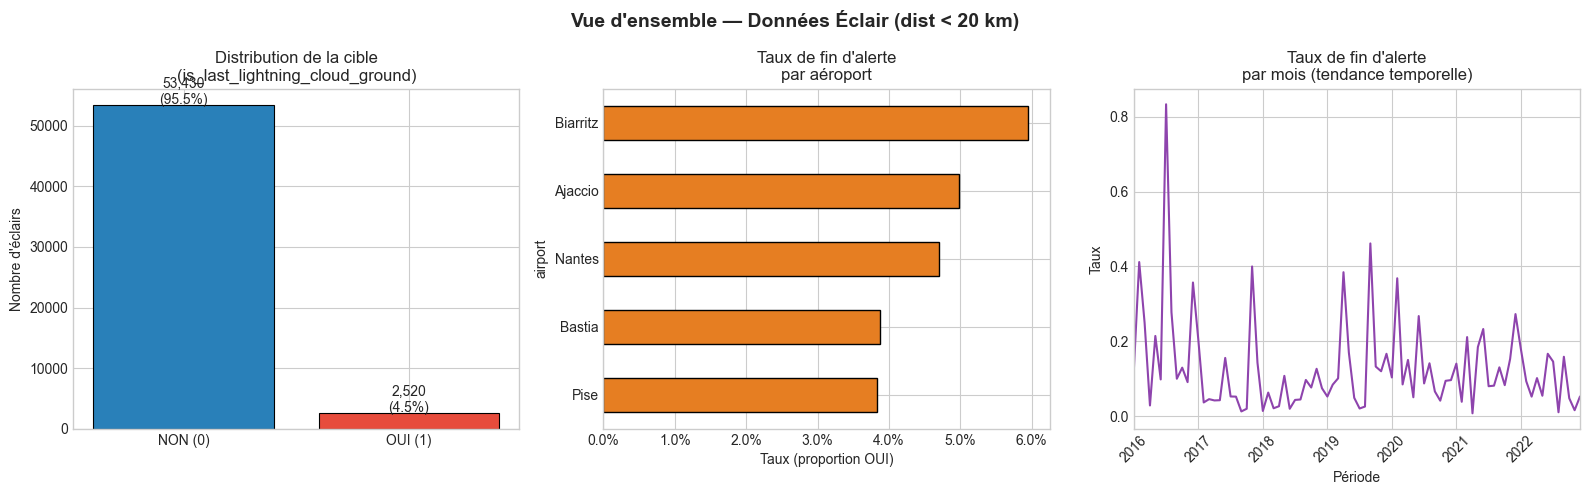

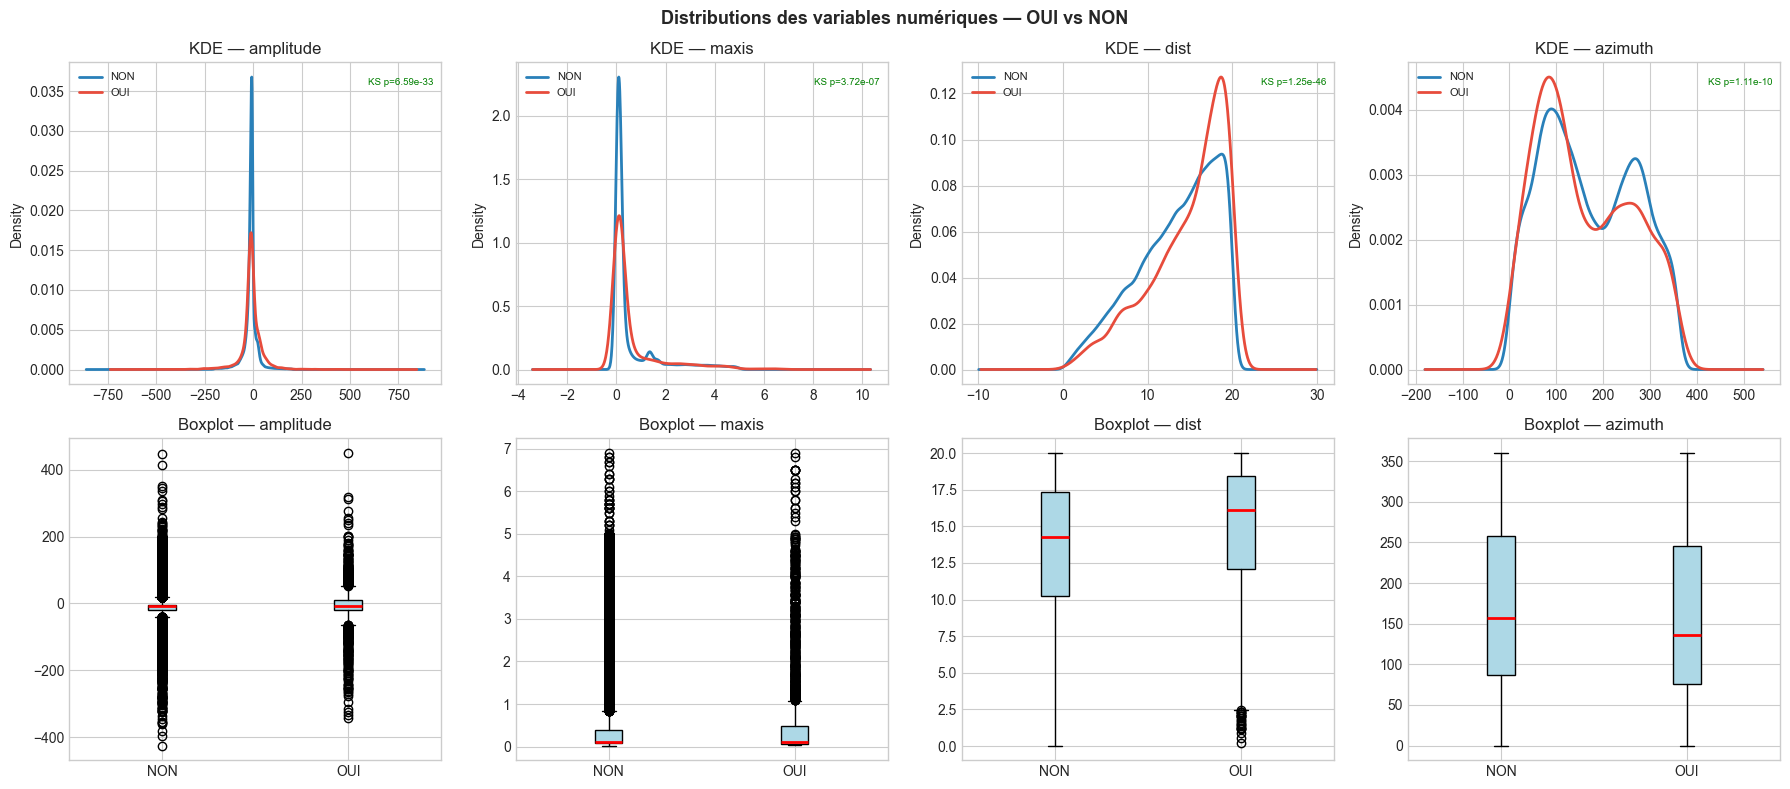

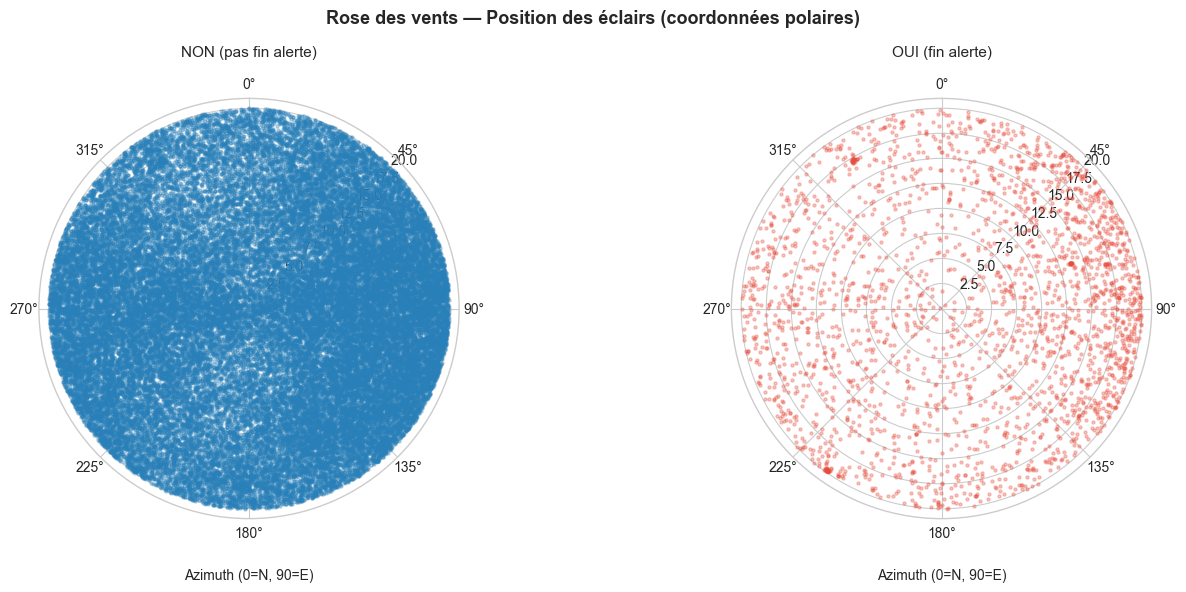

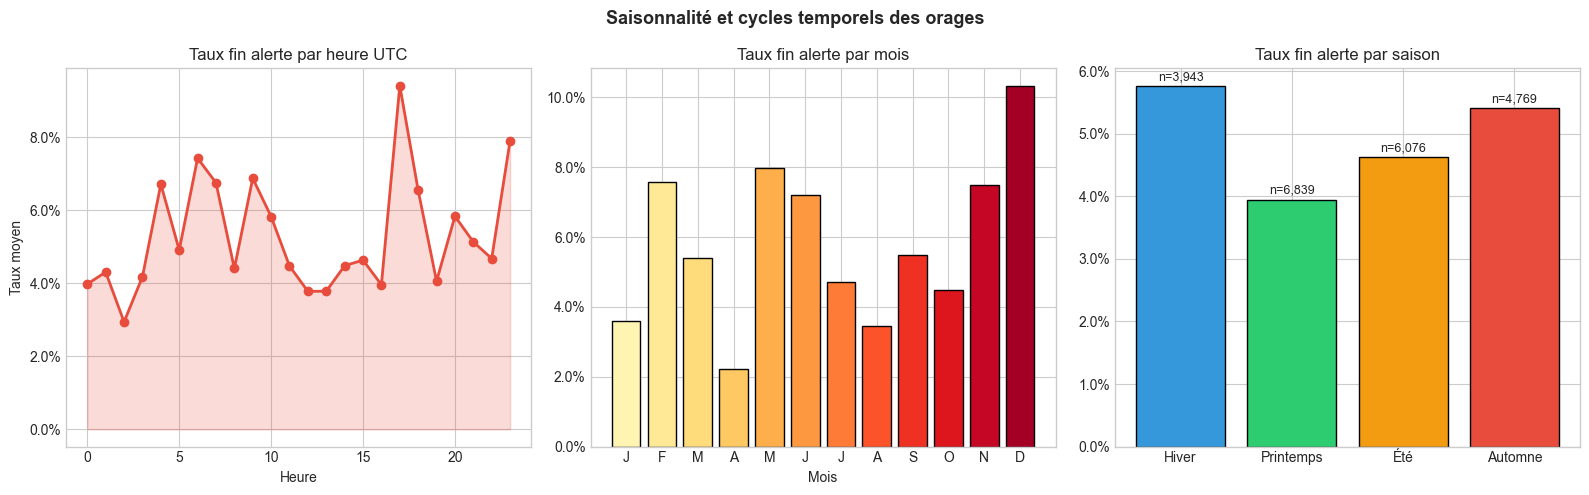


3. FEATURE ENGINEERING
Features construites : 20
X shape : (55950, 20) — Taux positif : 4.50%

4. FEATURE SELECTION

── Top 15 features (rang agrégé) ──
          feature       MI  RF_importance  Pearson_abs  mean_rank
 dist_x_amplitude 0.004638       0.099734     0.081127   3.333333
        amplitude 0.005423       0.103685     0.021355   3.666667
    abs_amplitude 0.004883       0.068430     0.069280   4.333333
log_abs_amplitude 0.004664       0.064569     0.072506   4.666667
             dist 0.002492       0.102727     0.058669   6.333333
        dayofyear 0.012433       0.045590     0.017428   6.666667
            x_pos 0.002783       0.064238     0.028929   7.333333
   amplitude_sign 0.002932       0.025633     0.060244   8.333333
            maxis 0.002571       0.092766     0.008004   9.666667
  is_cloud_ground 0.010940       0.000000          NaN  11.000000
          azimuth 0.001311       0.044600     0.021242  11.000000
      airport_enc 0.002723       0.037250     0.013425

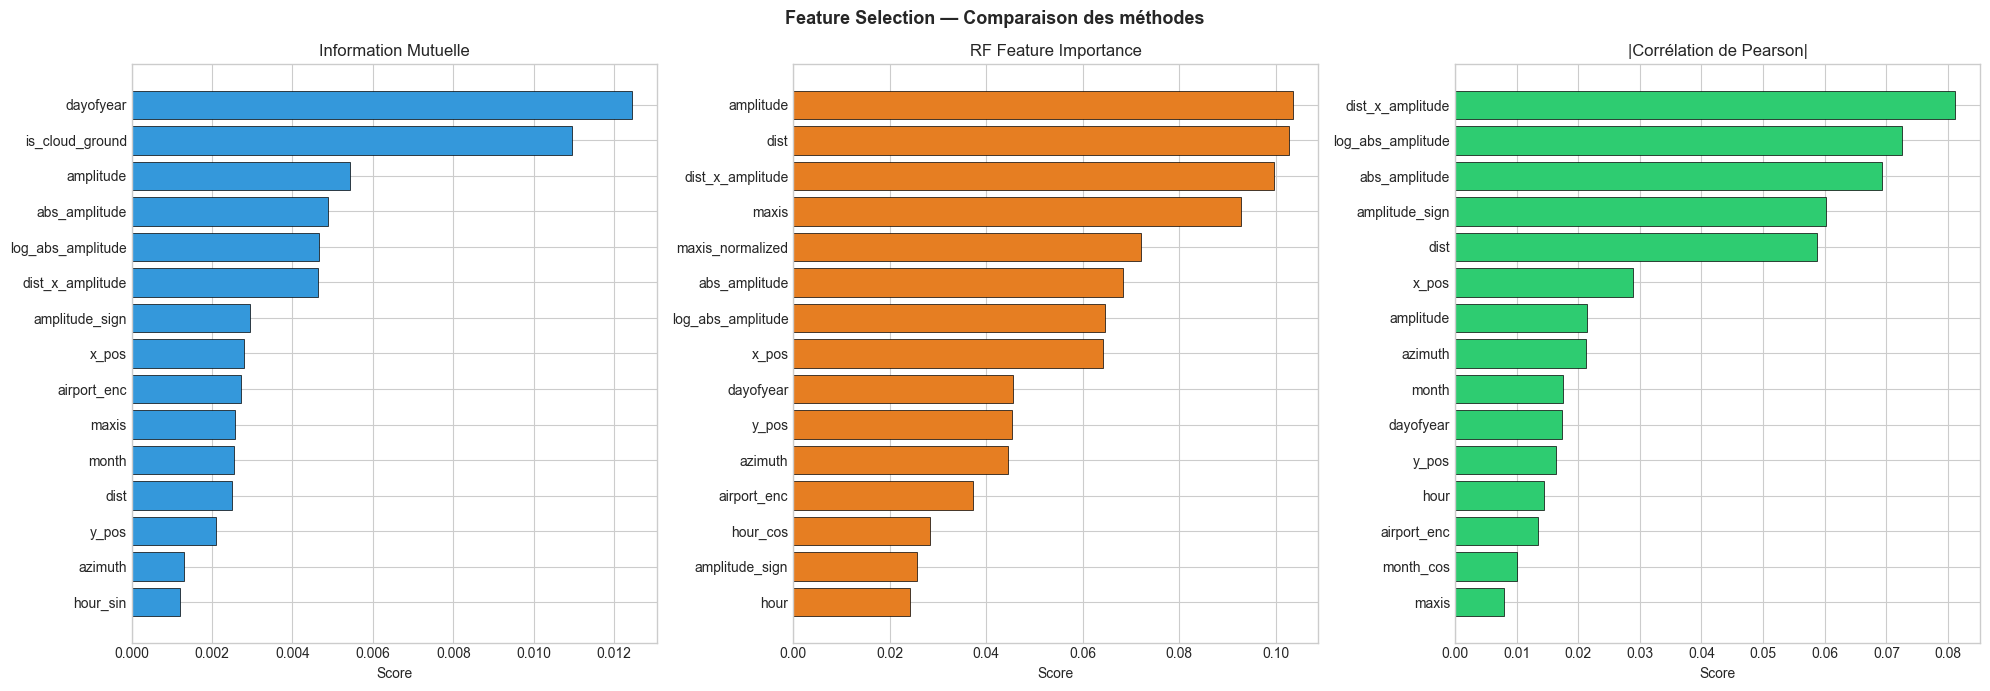

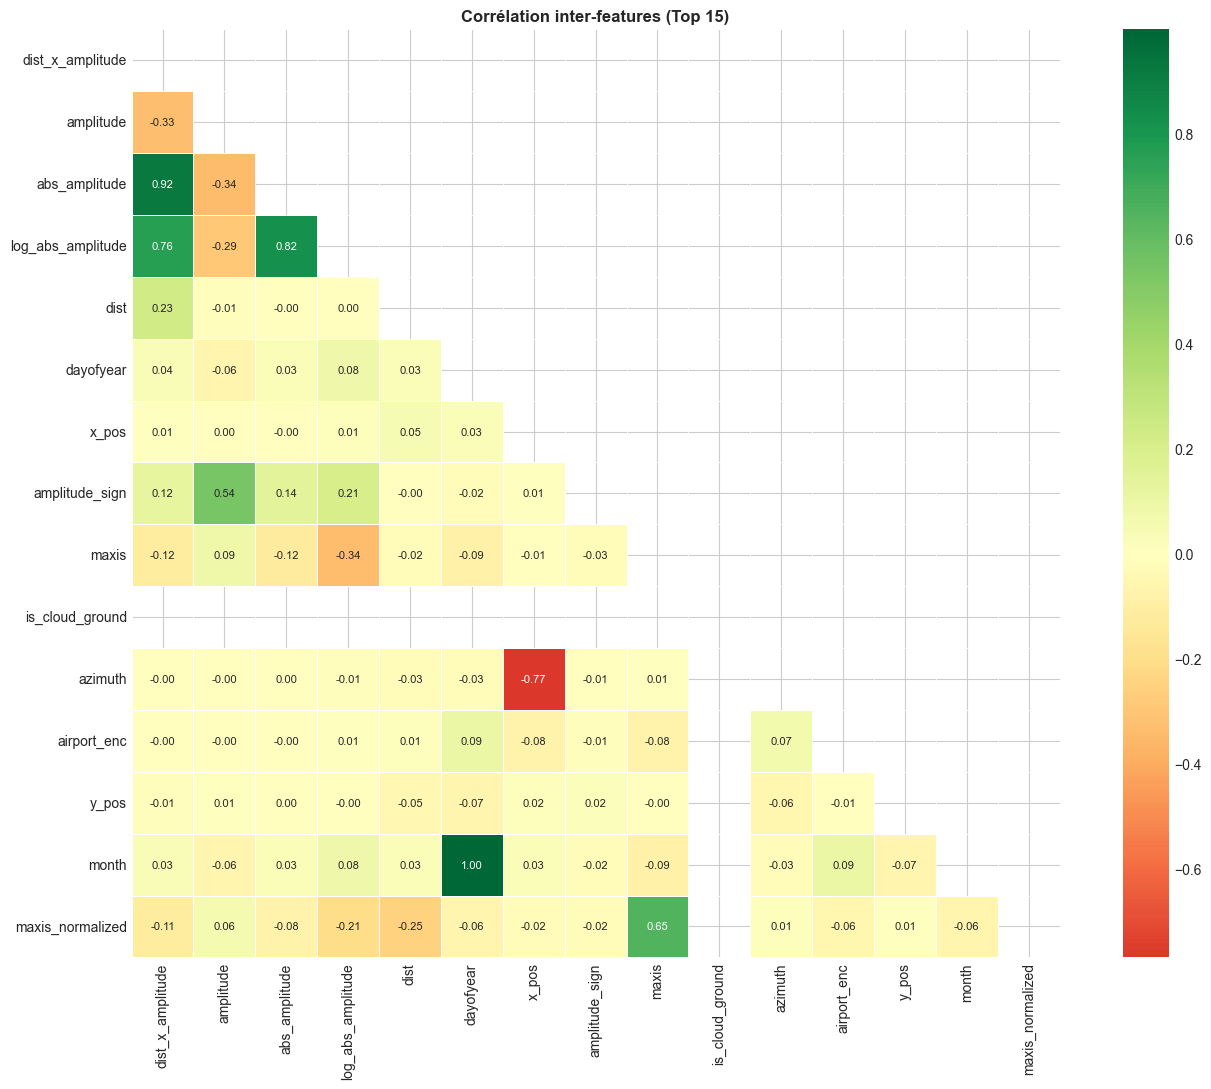


Features sélectionnées (12) : ['dist_x_amplitude', 'amplitude', 'abs_amplitude', 'log_abs_amplitude', 'dist', 'dayofyear', 'x_pos', 'amplitude_sign', 'maxis', 'is_cloud_ground', 'azimuth', 'airport_enc']

5. MACHINE LEARNING — CLASSIFICATION (classe déséquilibrée)
  Logistic Regression       | ROC-AUC=0.6478±0.0114 | AP=0.0828±0.0039
  Random Forest             | ROC-AUC=0.6958±0.0082 | AP=0.1086±0.0069
  Gradient Boosting         | ROC-AUC=0.7328±0.0101 | AP=0.1341±0.0040
  XGBoost                   | ROC-AUC=0.7302±0.0101 | AP=0.1325±0.0100

→ Meilleur modèle : Gradient Boosting


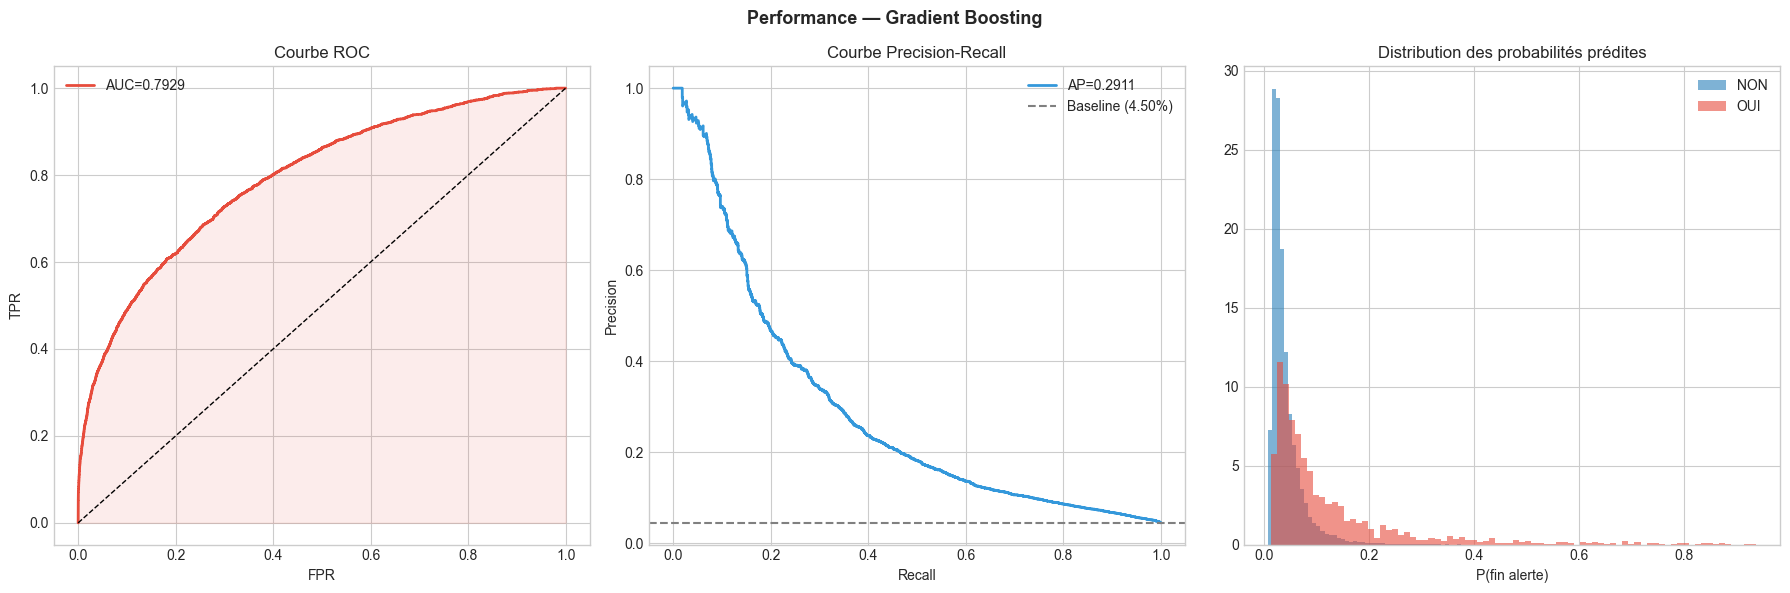


Seuil optimal F1 : 0.123 (F1=0.3216)

Classification Report :
              precision    recall  f1-score   support

         NON       0.97      0.97      0.97     53430
         OUI       0.33      0.31      0.32      2520

    accuracy                           0.94     55950
   macro avg       0.65      0.64      0.65     55950
weighted avg       0.94      0.94      0.94     55950



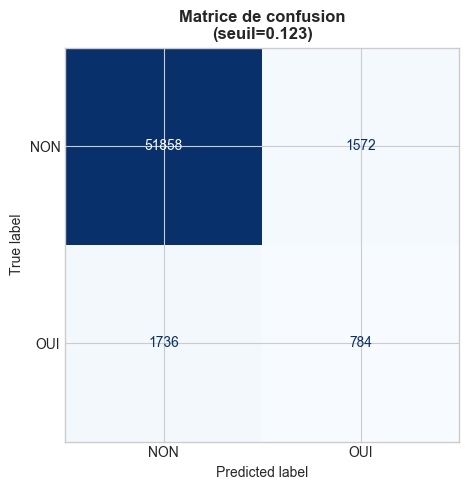


Calcul SHAP values...


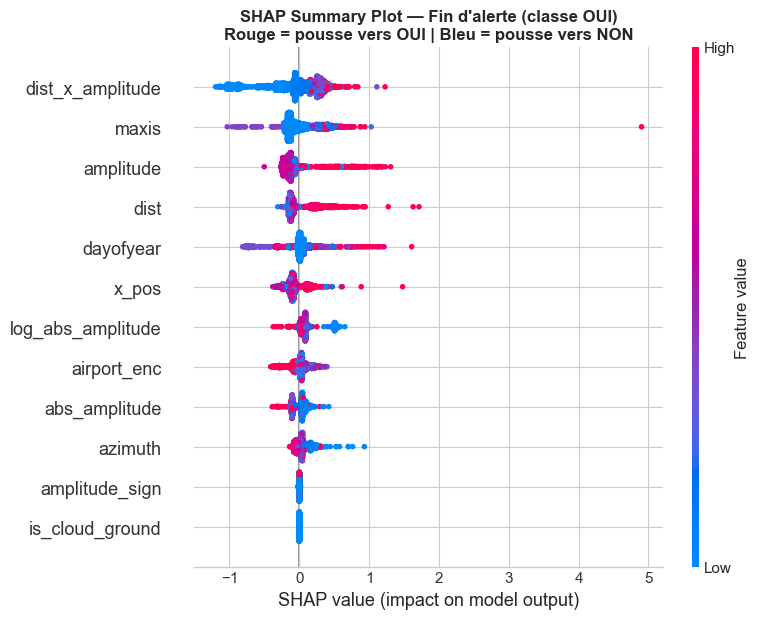

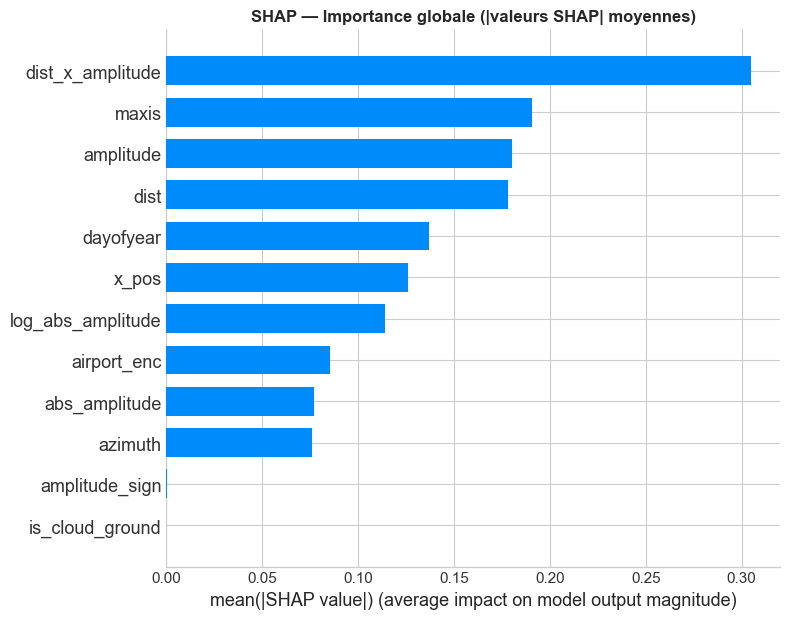

SHAP plots sauvegardés.

6. PROCESSUS STOCHASTIQUE — TEMPS D'ARRÊT & CHAÎNE DE MARKOV
Éclairs dans des alertes : 55,950
Alertes uniques : 2,520

Temps inter-éclairs (secondes) :
  Médiane : 27.0s | Moyenne : 91.5s | P95 : 393.0s

Fit loi exponentielle : λ = 0.0109 éclairs/s (0.66 éclairs/min)

Durée des alertes :
  Médiane : 27.3 min | Moyenne : 994.1 min | P95 : 159.4 min

Nombre d'éclairs par alerte :
  Médiane : 6 | Moyenne : 31.9 | P95 : 118


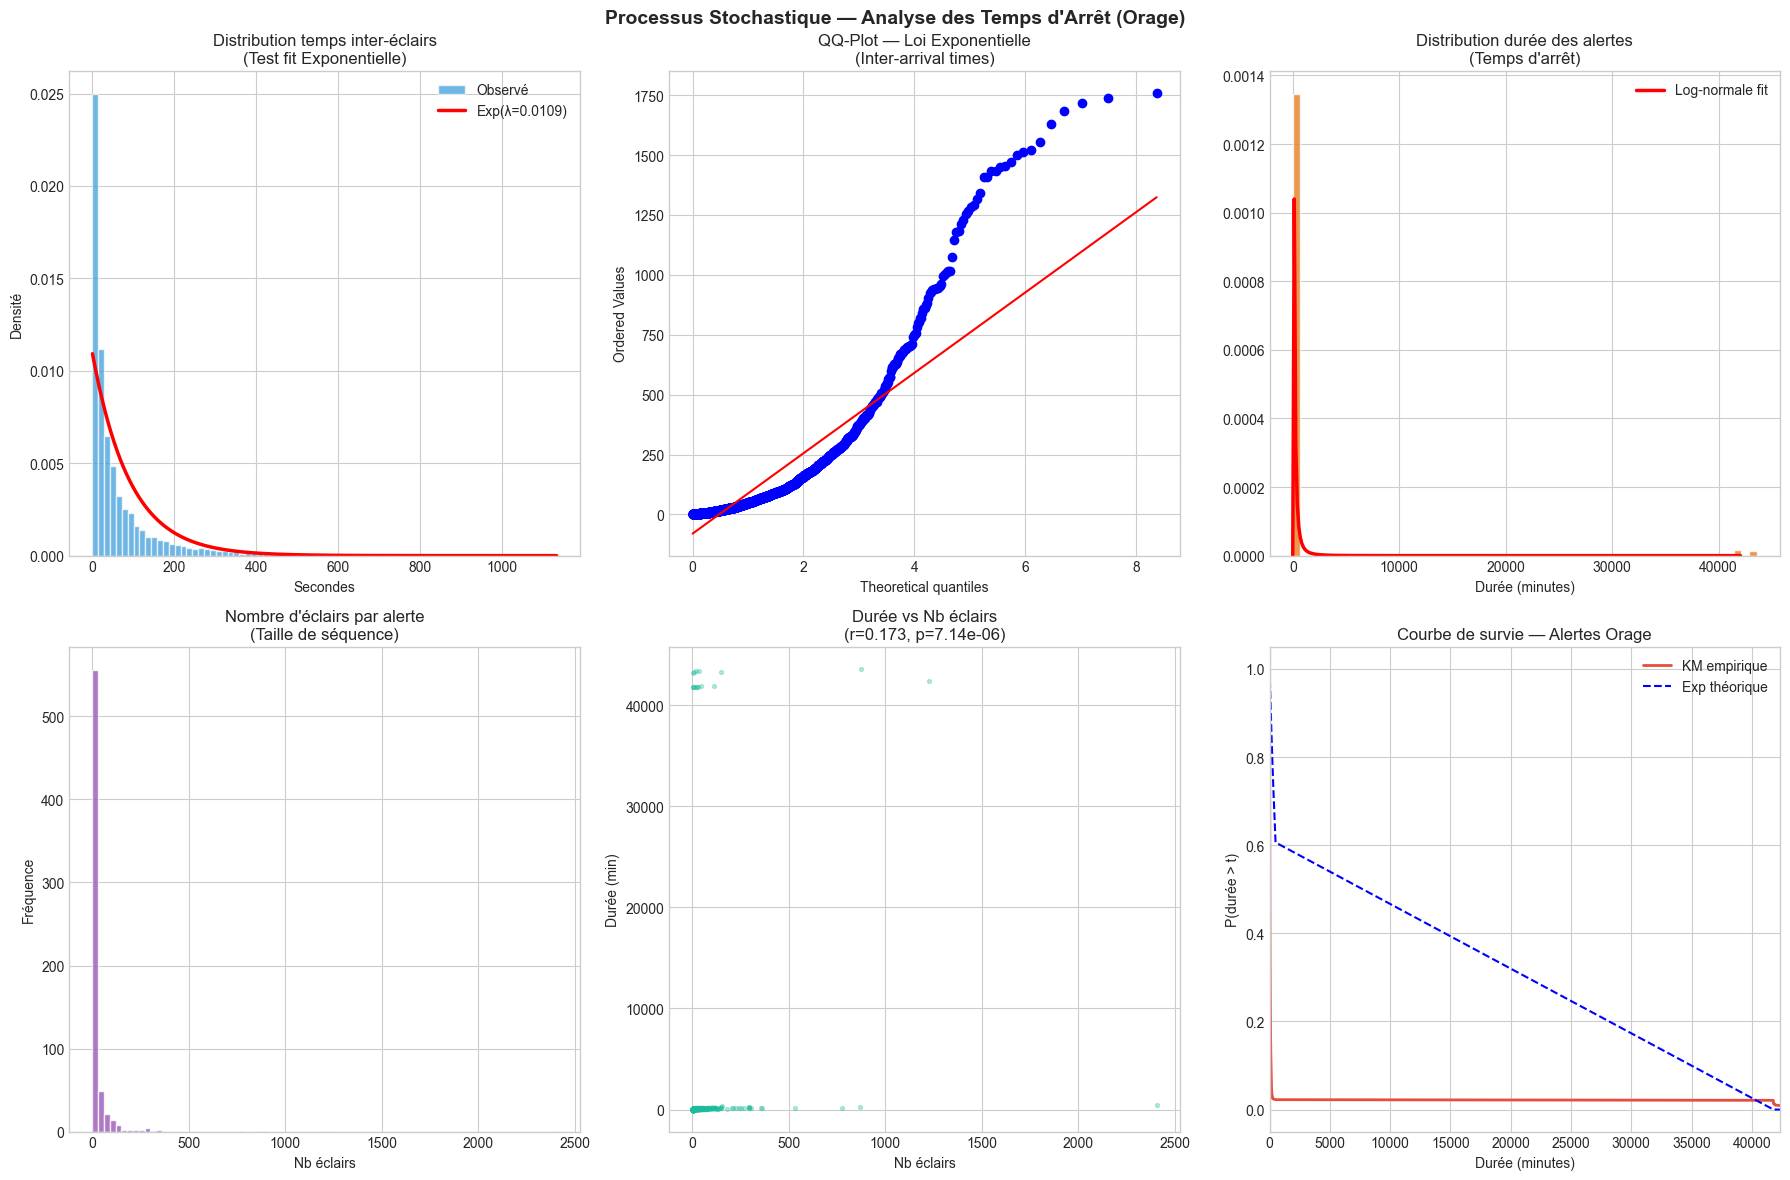


── Chaîne de Markov (zones de distance) ──

Matrice de transition P(état_t+1 | état_t) :
          0-5km  5-10km  10-15km  15-20km
0-5km    0.2613  0.2619   0.2299   0.2470
5-10km   0.0916  0.3398   0.2951   0.2734
10-15km  0.0423  0.1673   0.4148   0.3756
15-20km  0.0316  0.1099   0.2633   0.5952

Distribution stationnaire π :
  0-5km: 0.0593
  5-10km: 0.1779
  10-15km: 0.3147
  15-20km: 0.4482

Temps moyen d'absorption (éclairs) vers zone < 5km :
  Depuis 5-10km: 20.48 éclairs
  Depuis 10-15km: 21.83 éclairs
  Depuis 15-20km: 22.23 éclairs


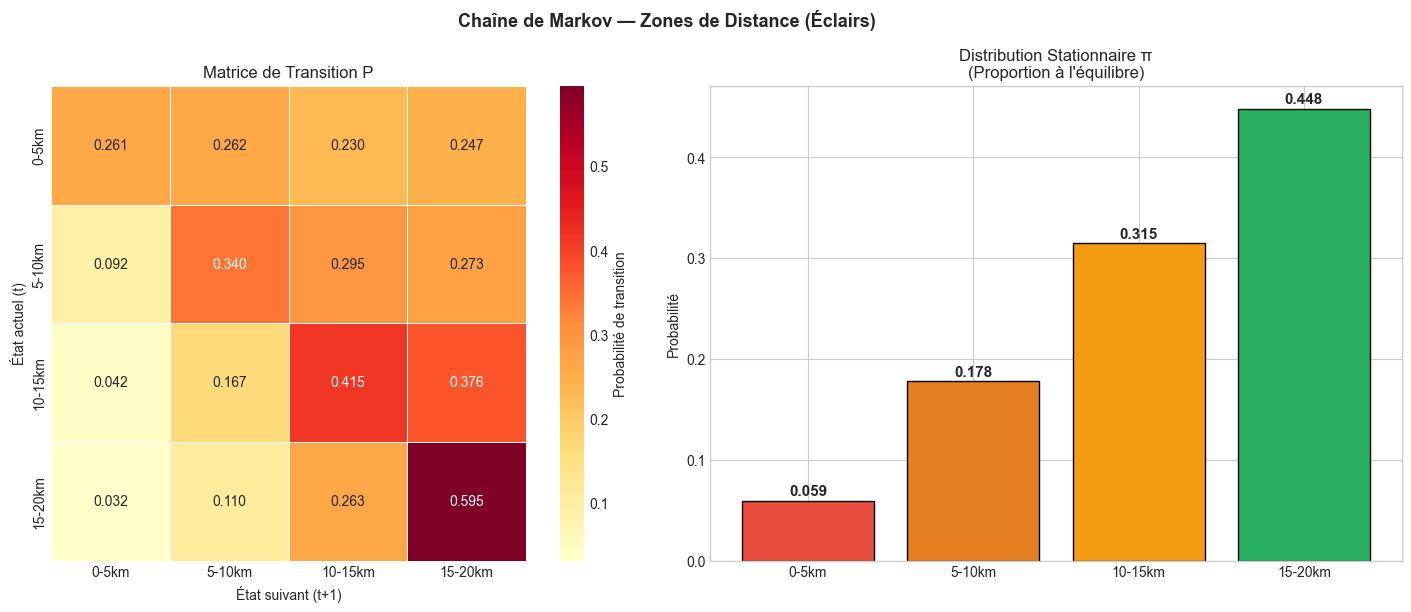


── Simulation Monte Carlo d'alertes (Chaîne de Markov) ──
Durée simulée (éclairs) : médiane=15, P95=65, max=215


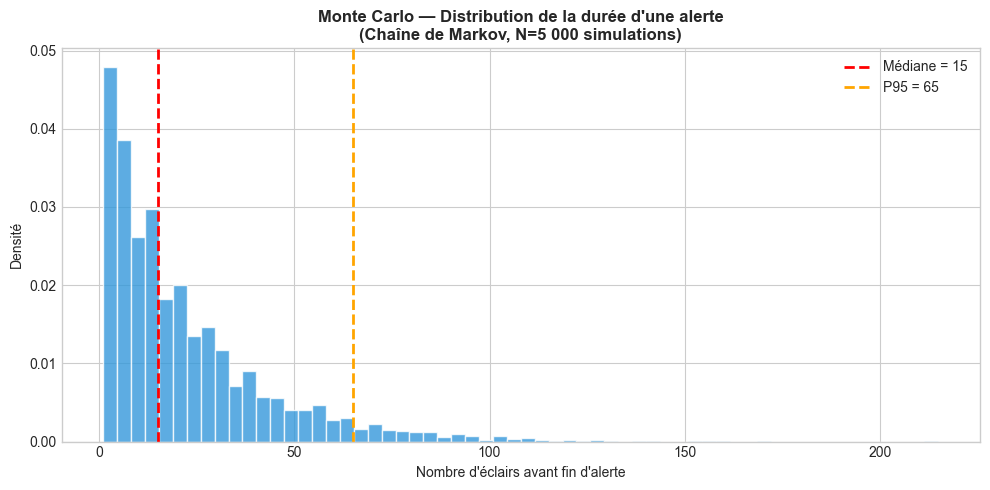


7. SYNTHÈSE DES RÉSULTATS

── Performances ML (CV 5-fold) ──
                     ROC-AUC      AP
Modèle                              
Logistic Regression   0.6478  0.0828
Random Forest         0.6958  0.1086
Gradient Boosting     0.7328  0.1341
XGBoost               0.7302  0.1325

── Meilleur modèle : Gradient Boosting ──
  Seuil optimal F1 : 0.123

── Chaîne de Markov ──
  Distribution stationnaire : {'0-5km': np.float64(0.0593), '5-10km': np.float64(0.1779), '10-15km': np.float64(0.3147), '15-20km': np.float64(0.4482)}

── Processus stochastique ──
  λ inter-éclairs : 0.0109/s = 0.66/min
  Durée médiane alerte : 27.3 min

Toutes les figures sauvegardées dans : ./figures/


In [12]:
"""
=============================================================================
THUNDERSTORM ANALYSIS PIPELINE — Data Scientist Spécialiste Orages
=============================================================================
Objectif : Prédire is_last_lightning_cloud_ground (fin d'alerte = 4% positif)
Pipeline  : EDA rigoureuse → Feature Engineering → Feature Selection →
            ML (classification déséquilibrée) → Processus Stochastique /
            Chaîne de Markov sur les temps d'arrêt
=============================================================================
"""

# ─────────────────────────────────────────────────────────────────────────────
# 0. IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, ks_2samp
import matplotlib.ticker as mtick

# ML
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_classif, SelectKBest, f_classif

# XGBoost (si disponible)
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost non disponible — on continue sans.")

# SHAP (si disponible)
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("SHAP non disponible — on continue sans.")

# imbalanced-learn
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    HAS_IMBLEARN = True
except ImportError:
    HAS_IMBLEARN = False
    print("imbalanced-learn non disponible — on continue sans SMOTE.")

plt.style.use("seaborn-v0_8-whitegrid")
PALETTE = {"OUI": "#e74c3c", "NON": "#2980b9"}
FIGDIR = "figures/"
import os
os.makedirs(FIGDIR, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# 1. CHARGEMENT & NETTOYAGE
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("1. CHARGEMENT DES DONNÉES")
print("=" * 70)

df = pd.read_csv('data_train_databattle2026\\segment_alerts_all_airports_train.csv')

print(f"Dimensions brutes : {df.shape}")
print(f"\nColonnes : {list(df.columns)}")
print(f"\nTypes :\n{df.dtypes}")
print(f"\nNaN par colonne :\n{df.isna().sum()}")

# ── Parsing date
df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")

# ── Normalisation booléens français
for col in ["icloud", "is_last_lightning_cloud_ground"]:
    if col in df.columns:
        df[col] = df[col].map(
            {"VRAI": True, "FAUX": False, True: True, False: False,
             "True": True, "False": False, 1: True, 0: False}
        )

# ── Filtrer Pise 2016 (enregistrement intra-nuage défaillant)
mask_pise_2016 = (df["airport"] == "Pise") & (df["date"].dt.year == 2016)
df_clean = df[~mask_pise_2016].copy()
print(f"\nAprès retrait Pise 2016 : {df_clean.shape}")

# ── Sous-ensemble étiqueté (is_last_lightning_cloud_ground renseigné)
df_labeled = df_clean[df_clean["is_last_lightning_cloud_ground"].notna()].copy()
df_labeled["target"] = df_labeled["is_last_lightning_cloud_ground"].astype(int)
print(f"\nLignes étiquetées (dist < 20 km) : {len(df_labeled):,}")
print(f"Taux positif (fin alerte) : {df_labeled['target'].mean():.2%}")

# ─────────────────────────────────────────────────────────────────────────────
# 2. EDA — VISUALISATIONS RIGOUREUSES
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("2. EDA — ANALYSE EXPLORATOIRE RIGOUREUSE")
print("=" * 70)

# ── 2.1 Distribution globale de la cible
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Vue d'ensemble — Données Éclair (dist < 20 km)", fontsize=14, fontweight="bold")

counts = df_labeled["target"].value_counts()
axes[0].bar(["NON (0)", "OUI (1)"], counts.values,
            color=[PALETTE["NON"], PALETTE["OUI"]], edgecolor="black", linewidth=0.8)
axes[0].set_title("Distribution de la cible\n(is_last_lightning_cloud_ground)")
axes[0].set_ylabel("Nombre d'éclairs")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f"{v:,}\n({v/counts.sum():.1%})", ha="center", fontsize=10)

# Répartition par aéroport
airport_target = df_labeled.groupby("airport")["target"].agg(["sum", "count"])
airport_target["rate"] = airport_target["sum"] / airport_target["count"]
airport_target["rate"].sort_values().plot(kind="barh", ax=axes[1],
    color="#e67e22", edgecolor="black")
axes[1].set_title("Taux de fin d'alerte\npar aéroport")
axes[1].set_xlabel("Taux (proportion OUI)")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Distribution temporelle (par année-mois)
df_labeled["ym"] = df_labeled["date"].dt.to_period("M")
monthly = df_labeled.groupby("ym")["target"].agg(["sum", "count"])
monthly["rate"] = monthly["sum"] / monthly["count"]
monthly["rate"].plot(ax=axes[2], color="#8e44ad", linewidth=1.5)
axes[2].set_title("Taux de fin d'alerte\npar mois (tendance temporelle)")
axes[2].set_xlabel("Période")
axes[2].set_ylabel("Taux")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{FIGDIR}01_overview.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 2.2 Variables numériques — distributions par classe
num_cols = ["amplitude", "maxis", "dist", "azimuth"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Distributions des variables numériques — OUI vs NON", fontsize=13, fontweight="bold")

for i, col in enumerate(num_cols):
    d0 = df_labeled[df_labeled["target"] == 0][col].dropna()
    d1 = df_labeled[df_labeled["target"] == 1][col].dropna()

    # KDE
    ax = axes[0, i]
    d0.plot.kde(ax=ax, color=PALETTE["NON"], label="NON", linewidth=2)
    d1.plot.kde(ax=ax, color=PALETTE["OUI"], label="OUI", linewidth=2)
    ax.set_title(f"KDE — {col}")
    ax.legend(fontsize=8)

    # Box plot
    ax2 = axes[1, i]
    ax2.boxplot([d0, d1], labels=["NON", "OUI"],
                patch_artist=True,
                boxprops=dict(facecolor="lightblue"),
                medianprops=dict(color="red", linewidth=2))
    ax2.set_title(f"Boxplot — {col}")

    # KS test
    ks_stat, ks_p = ks_2samp(d0, d1)
    ax.text(0.98, 0.95, f"KS p={ks_p:.2e}", transform=ax.transAxes,
            ha="right", va="top", fontsize=7,
            color="green" if ks_p < 0.05 else "gray")

plt.tight_layout()
plt.savefig(f"{FIGDIR}02_numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 2.3 Carte de chaleur azimuth × dist (Rose des vents)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw=dict(projection="polar"))
fig.suptitle("Rose des vents — Position des éclairs (coordonnées polaires)", fontsize=13, fontweight="bold")

for ax, (label, sub) in zip(axes, [("NON (pas fin alerte)", df_labeled[df_labeled["target"]==0]),
                                     ("OUI (fin alerte)", df_labeled[df_labeled["target"]==1])]):
    theta = np.radians(sub["azimuth"].dropna())
    r = sub["dist"].dropna()
    min_len = min(len(theta), len(r))
    ax.scatter(theta[:min_len], r[:min_len], alpha=0.3, s=5,
               c=PALETTE["OUI"] if "OUI" in label else PALETTE["NON"])
    ax.set_title(label, pad=15, fontsize=11)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_rlabel_position(45)
    ax.set_xlabel("Azimuth (0=N, 90=E)", labelpad=20)

plt.tight_layout()
plt.savefig(f"{FIGDIR}03_polar_rose.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 2.4 Analyse temporelle intra-journalière & saisonnalité
df_labeled["hour"] = df_labeled["date"].dt.hour
df_labeled["month"] = df_labeled["date"].dt.month
df_labeled["season"] = df_labeled["month"].map(
    {12: "Hiver", 1: "Hiver", 2: "Hiver",
     3: "Printemps", 4: "Printemps", 5: "Printemps",
     6: "Été", 7: "Été", 8: "Été",
     9: "Automne", 10: "Automne", 11: "Automne"})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Saisonnalité et cycles temporels des orages", fontsize=13, fontweight="bold")

# Heure
hourly = df_labeled.groupby("hour")["target"].mean()
axes[0].plot(hourly.index, hourly.values, "o-", color="#e74c3c", linewidth=2)
axes[0].fill_between(hourly.index, hourly.values, alpha=0.2, color="#e74c3c")
axes[0].set_title("Taux fin alerte par heure UTC")
axes[0].set_xlabel("Heure")
axes[0].set_ylabel("Taux moyen")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Mois
monthly_rate = df_labeled.groupby("month")["target"].mean()
axes[1].bar(monthly_rate.index, monthly_rate.values,
            color=sns.color_palette("YlOrRd", 12), edgecolor="black")
axes[1].set_title("Taux fin alerte par mois")
axes[1].set_xlabel("Mois")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Saison
season_order = ["Hiver", "Printemps", "Été", "Automne"]
season_data = df_labeled.groupby("season")["target"].agg(["mean", "count"])
season_data = season_data.reindex(season_order)
bars = axes[2].bar(season_data.index, season_data["mean"],
                   color=["#3498db", "#2ecc71", "#f39c12", "#e74c3c"],
                   edgecolor="black")
axes[2].set_title("Taux fin alerte par saison")
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
for bar, (_, row) in zip(bars, season_data.iterrows()):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f"n={int(row['count']):,}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(f"{FIGDIR}04_temporal_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 3. FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("3. FEATURE ENGINEERING")
print("=" * 70)

def build_features(df_in):
    d = df_in.copy()

    # ── Temporel
    d["hour"]         = d["date"].dt.hour
    d["minute"]       = d["date"].dt.minute
    d["month"]        = d["date"].dt.month
    d["dayofyear"]    = d["date"].dt.dayofyear
    d["hour_sin"]     = np.sin(2 * np.pi * d["hour"] / 24)
    d["hour_cos"]     = np.cos(2 * np.pi * d["hour"] / 24)
    d["month_sin"]    = np.sin(2 * np.pi * d["month"] / 12)
    d["month_cos"]    = np.cos(2 * np.pi * d["month"] / 12)

    # ── Géométrique (polaire → cartésien)
    az_rad = np.radians(d["azimuth"])
    d["x_pos"] = d["dist"] * np.sin(az_rad)
    d["y_pos"] = d["dist"] * np.cos(az_rad)

    # ── Intensité absolue
    d["abs_amplitude"] = d["amplitude"].abs()
    d["log_abs_amplitude"] = np.log1p(d["abs_amplitude"])
    d["amplitude_sign"] = (d["amplitude"] > 0).astype(int)

    # ── Quadrant géographique
    d["quadrant"] = pd.cut(d["azimuth"] % 360,
                            bins=[0, 90, 180, 270, 360],
                            labels=["N-E", "S-E", "S-O", "N-O"],
                            right=False)

    # ── Nature de l'éclair
    d["is_cloud_ground"] = (~d["icloud"].fillna(False)).astype(int)

    # ── Zones de distance (bandes concentriques)
    d["dist_band"] = pd.cut(d["dist"], bins=[0, 5, 10, 15, 20],
                             labels=["0-5km", "5-10km", "10-15km", "15-20km"])

    # ── Interaction dist × amplitude
    d["dist_x_amplitude"] = d["dist"] * d["abs_amplitude"]

    # ── Erreur de localisation normalisée
    d["maxis_normalized"] = d["maxis"] / (d["dist"] + 1e-3)

    return d

df_feat = build_features(df_labeled)

feature_cols = [
    "amplitude", "abs_amplitude", "log_abs_amplitude", "amplitude_sign",
    "maxis", "maxis_normalized",
    "dist", "azimuth", "x_pos", "y_pos",
    "hour", "hour_sin", "hour_cos",
    "month", "month_sin", "month_cos",
    "dayofyear",
    "is_cloud_ground",
    "dist_x_amplitude",
]
# Encodage aéroport
le_airport = LabelEncoder()
df_feat["airport_enc"] = le_airport.fit_transform(df_feat["airport"].astype(str))
feature_cols.append("airport_enc")

X = df_feat[feature_cols].fillna(0)
y = df_feat["target"]

print(f"Features construites : {len(feature_cols)}")
print(f"X shape : {X.shape} — Taux positif : {y.mean():.2%}")

# ─────────────────────────────────────────────────────────────────────────────
# 4. FEATURE SELECTION RIGOUREUSE
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("4. FEATURE SELECTION")
print("=" * 70)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── 4.1 Information Mutuelle
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({"feature": feature_cols, "MI": mi_scores}).sort_values("MI", ascending=False)

# ── 4.2 Random Forest importance
rf_sel = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                 random_state=42, n_jobs=-1, max_depth=8)
rf_sel.fit(X, y)
rf_imp = pd.DataFrame({
    "feature": feature_cols,
    "RF_importance": rf_sel.feature_importances_
}).sort_values("RF_importance", ascending=False)

# ── 4.3 Corrélation de Pearson (avec la cible)
pearson_corr = X.corrwith(y.astype(float)).abs().sort_values(ascending=False)
pearson_df = pd.DataFrame({"feature": pearson_corr.index, "Pearson_abs": pearson_corr.values})

# ── Consolidation
fs_merged = mi_df.merge(rf_imp, on="feature").merge(pearson_df, on="feature")
# Rang agrégé
for col in ["MI", "RF_importance", "Pearson_abs"]:
    fs_merged[f"rank_{col}"] = fs_merged[col].rank(ascending=False)
fs_merged["mean_rank"] = fs_merged[["rank_MI", "rank_RF_importance", "rank_Pearson_abs"]].mean(axis=1)
fs_merged = fs_merged.sort_values("mean_rank")

print("\n── Top 15 features (rang agrégé) ──")
print(fs_merged[["feature", "MI", "RF_importance", "Pearson_abs", "mean_rank"]].head(15).to_string(index=False))

# ── Visualisation feature selection
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Feature Selection — Comparaison des méthodes", fontsize=13, fontweight="bold")

for ax, (col, label, color) in zip(axes, [
    ("MI", "Information Mutuelle", "#3498db"),
    ("RF_importance", "RF Feature Importance", "#e67e22"),
    ("Pearson_abs", "|Corrélation de Pearson|", "#2ecc71")
]):
    top = fs_merged.nlargest(15, col)[["feature", col]].sort_values(col)
    ax.barh(top["feature"], top[col], color=color, edgecolor="black", linewidth=0.5)
    ax.set_title(label)
    ax.set_xlabel("Score")

plt.tight_layout()
plt.savefig(f"{FIGDIR}05_feature_selection.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Corrélation inter-features (multicolinéarité)
fig, ax = plt.subplots(figsize=(14, 11))
corr_matrix = X[fs_merged["feature"].head(15).tolist()].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=ax, linewidths=0.5, square=True,
            annot_kws={"size": 8})
ax.set_title("Corrélation inter-features (Top 15)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGDIR}06_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Sélection finale
TOP_N = 12
selected_features = fs_merged["feature"].head(TOP_N).tolist()
print(f"\nFeatures sélectionnées ({TOP_N}) : {selected_features}")
X_sel = X[selected_features]

# ─────────────────────────────────────────────────────────────────────────────
# 5. MACHINE LEARNING — CLASSIFICATION DÉSÉQUILIBRÉE
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("5. MACHINE LEARNING — CLASSIFICATION (classe déséquilibrée)")
print("=" * 70)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, C=0.1, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", max_depth=10,
        min_samples_leaf=10, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42),
}

if HAS_XGB:
    scale_pos = (y == 0).sum() / (y == 1).sum()
    models["XGBoost"] = xgb.XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        scale_pos_weight=scale_pos, subsample=0.8, colsample_bytree=0.8,
        eval_metric="aucpr", random_state=42, n_jobs=-1, verbosity=0)

results = {}
for name, model in models.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", model)])
    auc_scores = cross_val_score(pipe, X_sel, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    ap_scores  = cross_val_score(pipe, X_sel, y, cv=cv,
                                  scoring="average_precision", n_jobs=-1)
    results[name] = {
        "ROC-AUC": auc_scores.mean(),
        "ROC-AUC_std": auc_scores.std(),
        "AP": ap_scores.mean(),
        "AP_std": ap_scores.std(),
    }
    print(f"  {name:25s} | ROC-AUC={auc_scores.mean():.4f}±{auc_scores.std():.4f}"
          f" | AP={ap_scores.mean():.4f}±{ap_scores.std():.4f}")

# ── Entraînement du meilleur modèle (RF ou XGB)
best_name = max(results, key=lambda k: results[k]["AP"])
print(f"\n→ Meilleur modèle : {best_name}")

best_model_raw = models[best_name]
best_pipe = Pipeline([("scaler", StandardScaler()), ("clf", best_model_raw)])
best_pipe.fit(X_sel, y)

# ── Courbes ROC et PR sur train (pour visualisation — attention overfitting)
y_proba = best_pipe.predict_proba(X_sel)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f"Performance — {best_name}", fontsize=13, fontweight="bold")

# ROC
fpr, tpr, _ = roc_curve(y, y_proba)
auc_val = roc_auc_score(y, y_proba)
axes[0].plot(fpr, tpr, color="#e74c3c", lw=2, label=f"AUC={auc_val:.4f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("Courbe ROC")
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].legend()
axes[0].fill_between(fpr, tpr, alpha=0.1, color="#e74c3c")

# PR
prec, rec, thresholds = precision_recall_curve(y, y_proba)
ap_val = average_precision_score(y, y_proba)
axes[1].plot(rec, prec, color="#3498db", lw=2, label=f"AP={ap_val:.4f}")
axes[1].axhline(y.mean(), color="gray", linestyle="--", label=f"Baseline ({y.mean():.2%})")
axes[1].set_title("Courbe Precision-Recall")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

# Score calibration / distribution des proba
axes[2].hist(y_proba[y == 0], bins=80, color=PALETTE["NON"], alpha=0.6, label="NON", density=True)
axes[2].hist(y_proba[y == 1], bins=80, color=PALETTE["OUI"], alpha=0.6, label="OUI", density=True)
axes[2].set_title("Distribution des probabilités prédites")
axes[2].set_xlabel("P(fin alerte)")
axes[2].legend()

plt.tight_layout()
plt.savefig(f"{FIGDIR}07_model_performance.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Matrice de confusion (seuil optimisé F1)
from sklearn.metrics import f1_score
thresholds_f1 = np.linspace(0.01, 0.99, 200)
f1_vals = [f1_score(y, (y_proba >= t).astype(int)) for t in thresholds_f1]
best_thresh = thresholds_f1[np.argmax(f1_vals)]
print(f"\nSeuil optimal F1 : {best_thresh:.3f} (F1={max(f1_vals):.4f})")

y_pred_opt = (y_proba >= best_thresh).astype(int)
print("\nClassification Report :")
print(classification_report(y, y_pred_opt, target_names=["NON", "OUI"]))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y, y_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NON", "OUI"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Matrice de confusion\n(seuil={best_thresh:.3f})", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGDIR}08_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# ── SHAP (si disponible) pour le meilleur modèle
if HAS_SHAP and hasattr(best_pipe["clf"], "feature_importances_"):
    print("\nCalcul SHAP values...")
    X_sample = X_sel.sample(min(2000, len(X_sel)), random_state=42)

    # ── FIX : utiliser le scaler INTERNE au pipeline (fitté sur selected_features)
    pipe_scaler = best_pipe.named_steps["scaler"]
    X_sample_scaled = pipe_scaler.transform(X_sample)  # ndarray, ordre garanti
    # Reconstruire en DataFrame avec les bons noms de colonnes
    X_sample_scaled_df = pd.DataFrame(X_sample_scaled, columns=selected_features)

    explainer = shap.TreeExplainer(best_pipe.named_steps["clf"])

    # shap_values : liste (binary) ou ndarray selon la version de shap
    shap_values = explainer.shap_values(X_sample_scaled_df)

    fig, ax = plt.subplots(figsize=(12, 8))
    if isinstance(shap_values, list) and len(shap_values) == 2:
        # RandomForest ancien style : shap_values[1] = classe positive
        sv_plot = shap_values[1]
    else:
        # XGBoost / GBM / shap récent : ndarray direct
        sv_plot = shap_values

    shap.summary_plot(sv_plot, X_sample_scaled_df,
                      feature_names=selected_features,
                      show=False, plot_type="dot",
                      max_display=15)
    plt.title("SHAP Summary Plot — Fin d'alerte (classe OUI)\n"
              "Rouge = pousse vers OUI | Bleu = pousse vers NON",
              fontweight="bold", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{FIGDIR}09_shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── SHAP Bar plot (importance globale absolue)
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.summary_plot(sv_plot, X_sample_scaled_df,
                      feature_names=selected_features,
                      show=False, plot_type="bar",
                      max_display=15)
    plt.title("SHAP — Importance globale (|valeurs SHAP| moyennes)",
              fontweight="bold", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{FIGDIR}09b_shap_bar.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("SHAP plots sauvegardés.")

# ─────────────────────────────────────────────────────────────────────────────
# 6. PROCESSUS STOCHASTIQUE — TEMPS D'ARRÊT & CHAÎNE DE MARKOV
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("6. PROCESSUS STOCHASTIQUE — TEMPS D'ARRÊT & CHAÎNE DE MARKOV")
print("=" * 70)

"""
Modélisation stochastique d'un orage :
Chaque alerte = séquence d'éclairs jusqu'à is_last_lightning_cloud_ground = OUI
On modélise :
  (a) Distribution des temps inter-éclairs (processus de renouvellement)
  (b) Durée totale d'une alerte (temps d'arrêt = hitting time)
  (c) Chaîne de Markov : états = zones de distance {0-5, 5-10, 10-15, 15-20}
      Transitions entre éclairs successifs dans une même alerte
"""

# ── 6.1 Reconstruction des alertes
# On utilise airport_alert_id pour identifier les séquences
df_alerts = df_clean[df_clean["airport_alert_id"].notna()].copy()
df_alerts["date"] = pd.to_datetime(df_alerts["date"], dayfirst=True, errors="coerce")
df_alerts = df_alerts.sort_values(["airport", "airport_alert_id", "date"])

print(f"Éclairs dans des alertes : {len(df_alerts):,}")
print(f"Alertes uniques : {df_alerts.groupby(['airport', 'airport_alert_id']).ngroups:,}")

# ── Temps inter-éclairs (inter-arrival times)
df_alerts["inter_eclair_s"] = (
    df_alerts.groupby(["airport", "airport_alert_id"])["date"]
    .diff().dt.total_seconds()
)

inter_times = df_alerts["inter_eclair_s"].dropna()
inter_times = inter_times[(inter_times > 0) & (inter_times < 3600)]  # sanity

print(f"\nTemps inter-éclairs (secondes) :")
print(f"  Médiane : {inter_times.median():.1f}s | "
      f"Moyenne : {inter_times.mean():.1f}s | "
      f"P95 : {inter_times.quantile(0.95):.1f}s")

# Fit exponentielle (processus de Poisson)
lambda_hat = 1 / inter_times.mean()
print(f"\nFit loi exponentielle : λ = {lambda_hat:.4f} éclairs/s "
      f"({lambda_hat*60:.2f} éclairs/min)")

# ── Durée totale d'une alerte
alert_durations = df_alerts.groupby(["airport", "airport_alert_id"]).agg(
    duree_s=("date", lambda x: (x.max() - x.min()).total_seconds()),
    nb_eclairs=("lightning_id", "count"),
    dist_min=("dist", "min"),
    dist_max=("dist", "max"),
).reset_index()
alert_durations = alert_durations[alert_durations["duree_s"] > 0]

print(f"\nDurée des alertes :")
print(f"  Médiane : {alert_durations['duree_s'].median()/60:.1f} min | "
      f"Moyenne : {alert_durations['duree_s'].mean()/60:.1f} min | "
      f"P95 : {alert_durations['duree_s'].quantile(0.95)/60:.1f} min")
print(f"\nNombre d'éclairs par alerte :")
print(f"  Médiane : {alert_durations['nb_eclairs'].median():.0f} | "
      f"Moyenne : {alert_durations['nb_eclairs'].mean():.1f} | "
      f"P95 : {alert_durations['nb_eclairs'].quantile(0.95):.0f}")

# ── 6.2 Visualisation processus stochastique
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, figure=fig)
fig.suptitle("Processus Stochastique — Analyse des Temps d'Arrêt (Orage)", fontsize=14, fontweight="bold")

# Distribution temps inter-éclairs + fit exponentiel
ax1 = fig.add_subplot(gs[0, 0])
bins_iet = np.linspace(0, inter_times.quantile(0.99), 80)
ax1.hist(inter_times, bins=bins_iet, density=True, color="#3498db", alpha=0.7,
         edgecolor="white", label="Observé")
x_fit = np.linspace(0, inter_times.quantile(0.99), 300)
ax1.plot(x_fit, lambda_hat * np.exp(-lambda_hat * x_fit),
         "r-", lw=2.5, label=f"Exp(λ={lambda_hat:.4f})")
ax1.set_title("Distribution temps inter-éclairs\n(Test fit Exponentielle)")
ax1.set_xlabel("Secondes")
ax1.set_ylabel("Densité")
ax1.legend()

# Test de la loi exponentielle (QQ-plot)
ax2 = fig.add_subplot(gs[0, 1])
sample_exp = inter_times.sample(min(3000, len(inter_times)), random_state=42)
stats.probplot(sample_exp, dist=stats.expon, fit=True, plot=ax2)
ax2.set_title("QQ-Plot — Loi Exponentielle\n(Inter-arrival times)")

# Distribution durée alertes
ax3 = fig.add_subplot(gs[0, 2])
dur_min = alert_durations["duree_s"] / 60
ax3.hist(dur_min, bins=60, color="#e67e22", alpha=0.8, edgecolor="white", density=True)
# Fit log-normale
mu_fit, sigma_fit = stats.lognorm.fit(dur_min[dur_min > 0], floc=0)[2], stats.lognorm.fit(dur_min[dur_min > 0], floc=0)[0]
x_dur = np.linspace(0, dur_min.quantile(0.99), 300)
shape, loc, scale = stats.lognorm.fit(dur_min[dur_min > 0], floc=0)
ax3.plot(x_dur, stats.lognorm.pdf(x_dur, shape, loc, scale),
         "r-", lw=2.5, label=f"Log-normale fit")
ax3.set_title("Distribution durée des alertes\n(Temps d'arrêt)")
ax3.set_xlabel("Durée (minutes)")
ax3.legend()

# Nb éclairs par alerte
ax4 = fig.add_subplot(gs[1, 0])
nb_max = int(alert_durations["nb_eclairs"].quantile(0.99))
ax4.hist(alert_durations["nb_eclairs"], bins=min(nb_max, 80),
         color="#9b59b6", alpha=0.8, edgecolor="white")
ax4.set_title("Nombre d'éclairs par alerte\n(Taille de séquence)")
ax4.set_xlabel("Nb éclairs")
ax4.set_ylabel("Fréquence")

# Scatter durée vs nb éclairs
ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(alert_durations["nb_eclairs"],
            alert_durations["duree_s"] / 60,
            alpha=0.3, s=8, color="#1abc9c")
r, p = stats.pearsonr(alert_durations["nb_eclairs"],
                       alert_durations["duree_s"] / 60)
ax5.set_title(f"Durée vs Nb éclairs\n(r={r:.3f}, p={p:.2e})")
ax5.set_xlabel("Nb éclairs")
ax5.set_ylabel("Durée (min)")

# Survie (Kaplan-Meier manuel)
ax6 = fig.add_subplot(gs[1, 2])
dur_sorted = np.sort(alert_durations["duree_s"].values / 60)
surv = 1 - np.arange(1, len(dur_sorted) + 1) / len(dur_sorted)
ax6.plot(dur_sorted, surv, color="#e74c3c", lw=2, label="KM empirique")
# Exponentielle théorique
lam_alert = 1 / alert_durations["duree_s"].mean() * 60
ax6.plot(dur_sorted, np.exp(-lam_alert * dur_sorted), "b--", lw=1.5, label="Exp théorique")
ax6.set_title("Courbe de survie — Alertes Orage")
ax6.set_xlabel("Durée (minutes)")
ax6.set_ylabel("P(durée > t)")
ax6.legend()
ax6.set_xlim(0, dur_sorted[int(len(dur_sorted) * 0.99)])

plt.tight_layout()
plt.savefig(f"{FIGDIR}10_stochastic_process.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 6.3 CHAÎNE DE MARKOV — États = zones de distance
print("\n── Chaîne de Markov (zones de distance) ──")

# Définition des états
def get_dist_state(d):
    if d < 5:   return "0-5km"
    elif d < 10: return "5-10km"
    elif d < 15: return "10-15km"
    else:        return "15-20km"

STATES = ["0-5km", "5-10km", "10-15km", "15-20km"]
STATE_IDX = {s: i for i, s in enumerate(STATES)}

df_alerts["dist_state"] = df_alerts["dist"].apply(get_dist_state)

# Matrice de transition
n_states = len(STATES)
trans_counts = np.zeros((n_states, n_states), dtype=int)

for (airport, alert_id), grp in df_alerts.groupby(["airport", "airport_alert_id"]):
    states_seq = grp.sort_values("date")["dist_state"].tolist()
    for s_from, s_to in zip(states_seq[:-1], states_seq[1:]):
        trans_counts[STATE_IDX[s_from], STATE_IDX[s_to]] += 1

# Normalisation → matrice stochastique
row_sums = trans_counts.sum(axis=1, keepdims=True)
trans_matrix = np.where(row_sums > 0, trans_counts / row_sums, 0)

print("\nMatrice de transition P(état_t+1 | état_t) :")
trans_df = pd.DataFrame(trans_matrix, index=STATES, columns=STATES)
print(trans_df.round(4).to_string())

# Distribution stationnaire
eigenvalues, eigenvectors = np.linalg.eig(trans_matrix.T)
idx_unit = np.argmin(np.abs(eigenvalues - 1.0))
stationary = np.real(eigenvectors[:, idx_unit])
stationary = stationary / stationary.sum()
print(f"\nDistribution stationnaire π :")
for s, p in zip(STATES, stationary):
    print(f"  {s}: {p:.4f}")

# Temps d'absorption moyen (depuis chaque état, vers distance < 5km)
# Méthode : résolution du système linéaire (fundamental matrix)
try:
    # Q = sous-matrice transiente (états 1,2,3 → absorption en état 0)
    Q = trans_matrix[1:, 1:]  # 3×3 transiente
    R = trans_matrix[1:, :1]  # 3×1 vers absorption
    I = np.eye(Q.shape[0])
    N = np.linalg.inv(I - Q)  # Fundamental matrix
    t_abs = N.sum(axis=1)  # Temps moyen jusqu'à absorption
    print(f"\nTemps moyen d'absorption (éclairs) vers zone < 5km :")
    for s, t in zip(STATES[1:], t_abs):
        print(f"  Depuis {s}: {t:.2f} éclairs")
except np.linalg.LinAlgError:
    print("Matrice singulière — absorption non calculable.")

# ── Visualisation Chaîne de Markov
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Chaîne de Markov — Zones de Distance (Éclairs)", fontsize=13, fontweight="bold")

# Heatmap matrice de transition
sns.heatmap(trans_df, annot=True, fmt=".3f", cmap="YlOrRd",
            ax=axes[0], linewidths=0.5, square=True,
            cbar_kws={"label": "Probabilité de transition"})
axes[0].set_title("Matrice de Transition P")
axes[0].set_xlabel("État suivant (t+1)")
axes[0].set_ylabel("État actuel (t)")

# Distribution stationnaire + diagramme en barres
axes[1].bar(STATES, stationary,
            color=["#e74c3c", "#e67e22", "#f39c12", "#27ae60"],
            edgecolor="black")
axes[1].set_title("Distribution Stationnaire π\n(Proportion à l'équilibre)")
axes[1].set_ylabel("Probabilité")
for i, (s, p) in enumerate(zip(STATES, stationary)):
    axes[1].text(i, p + 0.005, f"{p:.3f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{FIGDIR}11_markov_chain.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 6.4 Simulation Monte Carlo — durée d'une alerte
print("\n── Simulation Monte Carlo d'alertes (Chaîne de Markov) ──")

N_SIM = 5000
MAX_STEPS = 500  # sécurité

def simulate_alert_markov(trans_matrix, start_state_idx, states, max_steps=MAX_STEPS):
    """Simule une alerte jusqu'à retour en zone < 5km (état 0 = absorption)."""
    state = start_state_idx
    steps = 0
    trajectory = [state]
    # Absorption = fin d'alerte quand on revient en 0 après en être sorti
    visited_outer = (state != 0)

    for _ in range(max_steps):
        prob = trans_matrix[state]
        if prob.sum() == 0:
            break
        next_state = np.random.choice(len(states), p=prob)
        trajectory.append(next_state)
        state = next_state
        steps += 1
        if visited_outer and state == 0:
            break
        if state != 0:
            visited_outer = True
    return steps, trajectory

np.random.seed(42)
sim_durations = []
for _ in range(N_SIM):
    start = np.random.choice([1, 2, 3])  # démarre en zone > 5km
    n_steps, _ = simulate_alert_markov(trans_matrix, start, STATES)
    sim_durations.append(n_steps)

sim_dur = np.array(sim_durations)
print(f"Durée simulée (éclairs) : médiane={np.median(sim_dur):.0f}, "
      f"P95={np.percentile(sim_dur, 95):.0f}, max={sim_dur.max():.0f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sim_dur, bins=60, color="#3498db", alpha=0.8, edgecolor="white", density=True)
ax.axvline(np.median(sim_dur), color="red", lw=2, linestyle="--",
           label=f"Médiane = {np.median(sim_dur):.0f}")
ax.axvline(np.percentile(sim_dur, 95), color="orange", lw=2, linestyle="--",
           label=f"P95 = {np.percentile(sim_dur, 95):.0f}")
ax.set_title("Monte Carlo — Distribution de la durée d'une alerte\n(Chaîne de Markov, N=5 000 simulations)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Nombre d'éclairs avant fin d'alerte")
ax.set_ylabel("Densité")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGDIR}12_monte_carlo.png", dpi=150, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 7. SYNTHÈSE FINALE
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("7. SYNTHÈSE DES RÉSULTATS")
print("=" * 70)

print("\n── Performances ML (CV 5-fold) ──")
res_df = pd.DataFrame(results).T
res_df.index.name = "Modèle"
print(res_df[["ROC-AUC", "AP"]].round(4).to_string())

print(f"\n── Meilleur modèle : {best_name} ──")
print(f"  Seuil optimal F1 : {best_thresh:.3f}")

print("\n── Chaîne de Markov ──")
print(f"  Distribution stationnaire : {dict(zip(STATES, np.round(stationary, 4)))}")

print("\n── Processus stochastique ──")
print(f"  λ inter-éclairs : {lambda_hat:.4f}/s = {lambda_hat*60:.2f}/min")
print(f"  Durée médiane alerte : {alert_durations['duree_s'].median()/60:.1f} min")

print(f"\n{'='*70}")
print("Toutes les figures sauvegardées dans : ./figures/")
print(f"{'='*70}")

In [ ]:


# =============================================================================
# 0. IMPORTS
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import ks_2samp
import matplotlib.ticker as mtick
import os
from datetime import timedelta

# ML
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, f1_score, brier_score_loss
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# XGBoost (optionnel mais recommandé)
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost non disponible — performance réduite possible.")

# Configuration
plt.style.use("seaborn-v0_8-whitegrid")
PALETTE = {"OUI": "#e74c3c", "NON": "#2980b9"}
FIGDIR = "figures_orage/"
os.makedirs(FIGDIR, exist_ok=True)

print("="*80)
print("THUNDERSTORM ANALYSIS PIPELINE — Data Scientist Spécialiste")
print("="*80)

# =============================================================================
# 1. CHARGEMENT ET PRÉPARATION
# =============================================================================
print("\n[1] CHARGEMENT DES DONNÉES")
print("-"*60)

df = pd.read_csv('data_train_databattle2026/segment_alerts_all_airports_train.csv', 
                 parse_dates=['date'], low_memory=False)
print(f"Dimensions brutes : {df.shape}")

# Nettoyage
df["date"] = pd.to_datetime(df["date"], utc=True)

# Normalisation booléens
for col in ["icloud", "is_last_lightning_cloud_ground"]:
    df[col] = df[col].map({"VRAI": True, "FAUX": False, True: True, False: False,
                           "True": True, "False": False, 1: True, 0: False})

# Filtrer Pise 2016 (problème intra-nuage)
mask_pise_2016 = (df["airport"] == "Pise") & (df["date"].dt.year == 2016)
df_clean = df[~mask_pise_2016].copy()
print(f"Après retrait Pise 2016 : {df_clean.shape}")

# Sous-ensemble étiqueté (éclairs dans zone alerte < 20km)
df_labeled = df_clean[df_clean["is_last_lightning_cloud_ground"].notna()].copy()
df_labeled["target"] = df_labeled["is_last_lightning_cloud_ground"].astype(int)
print(f"Éclairs étiquetés (zone alerte) : {len(df_labeled):,}")
print(f"Taux positif (fin alerte) : {df_labeled['target'].mean():.2%}")
print(f"Déséquilibre 1:{df_labeled['target'].value_counts()[0] // df_labeled['target'].value_counts()[1]}")

# =============================================================================
# 2. FEATURE ENGINEERING AVANCÉ
# =============================================================================
print("\n[2] FEATURE ENGINEERING")
print("-"*60)

def build_advanced_features(df_in):
    """Construit des features basées sur l'EDA approfondie"""
    d = df_in.copy()
    d = d.sort_values(['airport', 'airport_alert_id', 'date'])
    
    # === FEATURES TEMPORELLES ===
    d['hour'] = d['date'].dt.hour
    d['minute'] = d['date'].dt.minute
    d['month'] = d['date'].dt.month
    d['dayofyear'] = d['date'].dt.dayofyear
    
    # Encodage circulaire (critique pour cycles jour/nuit et saisons)
    d['hour_sin'] = np.sin(2 * np.pi * d['hour'] / 24)
    d['hour_cos'] = np.cos(2 * np.pi * d['hour'] / 24)
    d['month_sin'] = np.sin(2 * np.pi * d['month'] / 12)
    d['month_cos'] = np.cos(2 * np.pi * d['month'] / 12)
    
    # === FEATURES D'INTER-TEMPS (LA PLUS IMPORTANTE SELON EDA) ===
    # Inter-temps depuis dernier éclair dans l'alerte
    d['inter_time_s'] = d.groupby(['airport', 'airport_alert_id'])['date'].diff().dt.total_seconds()
    d['inter_time_s'] = d['inter_time_s'].fillna(0)
    
    # Inter-temps rolling (moyenne des 3 derniers)
    d['inter_time_ma3'] = d.groupby(['airport', 'airport_alert_id'])['inter_time_s'].transform(
        lambda x: x.rolling(3, min_periods=1).mean()
    )
    
    # Ratio inter-temps courant / inter-temps moyen de l'alerte
    d['mean_inter_alert'] = d.groupby(['airport', 'airport_alert_id'])['inter_time_s'].transform('mean')
    d['inter_ratio'] = d['inter_time_s'] / (d['mean_inter_alert'] + 1e-6)
    
    # === FEATURES DE POSITION DANS L'ALERTE ===
    d['strike_num'] = d.groupby(['airport', 'airport_alert_id']).cumcount() + 1
    d['total_in_alert'] = d.groupby(['airport', 'airport_alert_id'])['lightning_id'].transform('count')
    d['progress_ratio'] = d['strike_num'] / d['total_in_alert']
    
    # === FEATURES D'INTENSITÉ ===
    d['abs_amplitude'] = d['amplitude'].abs()
    d['log_abs_amplitude'] = np.log1p(d['abs_amplitude'])
    d['amplitude_sign'] = (d['amplitude'] > 0).astype(int)  # 16% positifs, souvent en fin d'orage
    
    # Amplitude cumulée
    d['cumul_amplitude'] = d.groupby(['airport', 'airport_alert_id'])['abs_amplitude'].cumsum()
    
    # Tendance amplitude (pente sur 3 derniers)
    d['amp_trend'] = d.groupby(['airport', 'airport_alert_id'])['abs_amplitude'].transform(
        lambda x: x.rolling(3, min_periods=1).apply(lambda y: y.iloc[-1] - y.iloc[0] if len(y) > 1 else 0)
    )
    
    # === FEATURES SPATIALES ===
    # Conversion polaire → cartésien
    az_rad = np.radians(d['azimuth'])
    d['x_pos'] = d['dist'] * np.sin(az_rad)
    d['y_pos'] = d['dist'] * np.cos(az_rad)
    
    # Distance à l'aéroport (feature faible seule, mais utile en combinaison)
    d['dist_normalized'] = d['dist'] / 20  # normalisée sur rayon d'alerte
    
    # Zones de distance (pour la chaîne de Markov)
    d['dist_zone'] = pd.cut(d['dist'], bins=[0, 5, 10, 15, 20], 
                            labels=['0-5km', '5-10km', '10-15km', '15-20km'])
    
    # === FEATURES D'ACTIVITÉ RÉCENTE ===
    # Comptage sur fenêtres glissantes (5, 10, 15 minutes)
    for window in [5, 10, 15]:
        # Nombre d'éclairs dans les X dernières minutes
        d[f'n_last_{window}min'] = d.groupby(['airport', 'airport_alert_id'])['date'].transform(
            lambda x: x.rolling(f'{window}min', closed='left').count()
        ).fillna(0)
        
        # Proportion d'éclairs positifs dans la fenêtre
        d[f'pct_pos_last_{window}min'] = d.groupby(['airport', 'airport_alert_id'])['amplitude_sign'].transform(
            lambda x: x.rolling(f'{window}min', closed='left').mean()
        ).fillna(0)
    
    # Taux d'éclairs (par minute)
    d['strike_rate'] = d['n_last_5min'] / 5
    
    # === INTERACTION DISTANCE × AMPLITUDE ===
    d['dist_x_amplitude'] = d['dist'] * d['abs_amplitude']
    
    return d

# Application
df_feat = build_advanced_features(df_labeled)

# Liste des features (exclure les colonnes non-numériques)
exclude_cols = ['airport', 'date', 'lightning_id', 'lightning_airport_id', 
                'airport_alert_id', 'is_last_lightning_cloud_ground', 'target',
                'dist_zone', 'icloud']
feature_cols = [c for c in df_feat.columns if c not in exclude_cols and df_feat[c].dtype in ['int64', 'float64']]

print(f"Features construites : {len(feature_cols)}")
print("\nTop 10 features par corrélation avec la cible:")
corr_with_target = df_feat[feature_cols].corrwith(df_feat['target']).abs().sort_values(ascending=False)
for f, c in corr_with_target.head(10).items():
    print(f"  {f:20s} : {c:.4f}")

# Encodage aéroport
le_airport = LabelEncoder()
df_feat['airport_enc'] = le_airport.fit_transform(df_feat['airport'].astype(str))
feature_cols.append('airport_enc')

X = df_feat[feature_cols].fillna(0)
y = df_feat['target']

print(f"\nMatrice finale : X {X.shape}, y {y.sum()} positifs ({y.mean():.2%})")

# =============================================================================
# 3. SPLIT TEMPOREL (pas de fuite de données)
# =============================================================================
print("\n[3] SPLIT TEMPOREL")
print("-"*60)

# Split par date (80% premières années, 20% dernières)
dates = df_feat['date'].sort_values()
split_date = dates.quantile(0.8, interpolation='higher')

train_mask = df_feat['date'] <= split_date
test_mask = df_feat['date'] > split_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Train: {len(X_train)} éclairs ({train_mask.sum()/len(df_feat):.1%})")
print(f"Test:  {len(X_test)} éclairs ({test_mask.sum()/len(df_feat):.1%})")
print(f"Taux positif train: {y_train.mean():.2%}, test: {y_test.mean():.2%}")

# Standardisation
scaler = RobustScaler()  # Robuste aux outliers
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =============================================================================
# 4. MODÉLISATION ML AVEC GESTION DU DÉSÉQUILIBRE
# =============================================================================
print("\n[4] MODÉLISATION MACHINE LEARNING")
print("-"*60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Scale pos weight: {scale_pos:.1f}")

models = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced', C=0.1, max_iter=1000, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=42
    )
}

if HAS_XGB:
    models["XGBoost"] = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pos, subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, n_jobs=-1
    )

results = {}
for name, model in models.items():
    print(f"\n▶ {name}")
    pipe = Pipeline([('scaler', RobustScaler()), ('clf', model)])
    
    # Validation croisée
    ap_scores = cross_val_score(pipe, X_train, y_train, cv=cv, 
                                scoring='average_precision', n_jobs=-1)
    auc_scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                                 scoring='roc_auc', n_jobs=-1)
    
    print(f"  CV AP: {ap_scores.mean():.4f} ± {ap_scores.std():.4f}")
    print(f"  CV AUC: {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")
    
    # Entraînement final
    pipe.fit(X_train, y_train)
    y_pred_proba = pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    # Métriques test
    ap_test = average_precision_score(y_test, y_pred_proba)
    auc_test = roc_auc_score(y_test, y_pred_proba)
    f1_test = f1_score(y_test, y_pred)
    brier_test = brier_score_loss(y_test, y_pred_proba)
    
    results[name] = {
        'model': pipe,
        'ap': ap_test,
        'auc': auc_test,
        'f1': f1_test,
        'brier': brier_test,
        'proba': y_pred_proba,
        'pred': y_pred
    }
    print(f"  Test AP: {ap_test:.4f}, AUC: {auc_test:.4f}, F1: {f1_test:.4f}")

# Meilleur modèle (par Average Precision)
best_name = max(results, key=lambda k: results[k]['ap'])
best_model = results[best_name]['model']
print(f"\n🏆 Meilleur modèle: {best_name} (AP={results[best_name]['ap']:.4f})")

# =============================================================================
# 5. OPTIMISATION DU SEUIL
# =============================================================================
print("\n[5] OPTIMISATION DU SEUIL DE DÉCISION")
print("-"*60)

y_proba_train = best_model.predict_proba(X_train)[:, 1]
thresholds = np.linspace(0.01, 0.99, 100)
f1_scores = [f1_score(y_train, (y_proba_train >= t).astype(int)) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f"Seuil optimal F1: {best_thresh:.3f} (F1={best_f1:.4f})")

# Application sur test
y_pred_opt = (results[best_name]['proba'] >= best_thresh).astype(int)
print("\nClassification Report (seuil optimal):")
print(classification_report(y_test, y_pred_opt, target_names=['NON', 'OUI']))

# =============================================================================
# 6. VISUALISATIONS ML
# =============================================================================
print("\n[6] GÉNÉRATION DES VISUALISATIONS")
print("-"*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(f"Analyse ML — Modèle {best_name}", fontsize=14, fontweight='bold')

# 1. Courbe ROC
fpr, tpr, _ = roc_curve(y_test, results[best_name]['proba'])
axes[0,0].plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {results[best_name]["auc"]:.3f}')
axes[0,0].plot([0,1], [0,1], 'k--', alpha=0.5)
axes[0,0].set_xlabel('False Positive Rate')
axes[0,0].set_ylabel('True Positive Rate')
axes[0,0].set_title('Courbe ROC')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Courbe Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, results[best_name]['proba'])
axes[0,1].plot(rec, prec, 'r-', lw=2, label=f'AP = {results[best_name]["ap"]:.3f}')
axes[0,1].axhline(y_test.mean(), color='gray', linestyle='--', label=f'Baseline ({y_test.mean():.2%})')
axes[0,1].set_xlabel('Recall')
axes[0,1].set_ylabel('Precision')
axes[0,1].set_title('Courbe Precision-Recall')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Distribution des probabilités
axes[0,2].hist(results[best_name]['proba'][y_test==0], bins=50, alpha=0.6, 
               color=PALETTE['NON'], label='NON', density=True)
axes[0,2].hist(results[best_name]['proba'][y_test==1], bins=50, alpha=0.6,
               color=PALETTE['OUI'], label='OUI', density=True)
axes[0,2].axvline(best_thresh, color='red', linestyle='--', label=f'Seuil={best_thresh:.2f}')
axes[0,2].set_xlabel('P(fin alerte)')
axes[0,2].set_ylabel('Densité')
axes[0,2].set_title('Distribution des probabilités')
axes[0,2].legend()

# 4. Matrice de confusion
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,0],
            xticklabels=['NON', 'OUI'], yticklabels=['NON', 'OUI'])
axes[1,0].set_title(f'Matrice de confusion (seuil={best_thresh:.2f})')
axes[1,0].set_xlabel('Prédit')
axes[1,0].set_ylabel('Réel')

# 5. Calibration
prob_true, prob_pred = calibration_curve(y_test, results[best_name]['proba'], n_bins=10)
axes[1,1].plot(prob_pred, prob_true, 'o-', label='Modèle')
axes[1,1].plot([0,1], [0,1], 'k--', label='Parfait')
axes[1,1].set_xlabel('Probabilité prédite moyenne')
axes[1,1].set_ylabel('Fréquence observée')
axes[1,1].set_title(f'Calibration (Brier={results[best_name]["brier"]:.4f})')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# 6. Comparaison des modèles
models_comp = pd.DataFrame({
    name: {'AP': res['ap'], 'AUC': res['auc'], 'F1': res['f1']}
    for name, res in results.items()
}).T
models_comp.plot(kind='bar', ax=axes[1,2])
axes[1,2].set_title('Comparaison des modèles')
axes[1,2].set_xlabel('')
axes[1,2].set_ylabel('Score')
axes[1,2].legend(loc='lower right')
axes[1,2].set_xticklabels(axes[1,2].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig(f'{FIGDIR}ml_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Figure sauvegardée: {FIGDIR}ml_performance.png")

# =============================================================================
# 7. CHAÎNE DE MARKOV — PROCESSUS STOCHASTIQUE
# =============================================================================
print("\n[7] CHAÎNE DE MARKOV — ANALYSE STOCHASTIQUE")
print("-"*60)

# Reconstruction des alertes
df_alerts = df_clean[df_clean['airport_alert_id'].notna()].copy()
df_alerts = df_alerts.sort_values(['airport', 'airport_alert_id', 'date'])

# Zones de distance
def get_zone(d):
    if d < 5: return "0-5km"
    elif d < 10: return "5-10km"
    elif d < 15: return "10-15km"
    else: return "15-20km"

df_alerts['zone'] = df_alerts['dist'].apply(get_zone)
ZONES = ["0-5km", "5-10km", "10-15km", "15-20km"]
zone_to_idx = {z:i for i,z in enumerate(ZONES)}

# Matrice de transition
trans_matrix = np.zeros((4,4))
for _, grp in df_alerts.groupby(['airport', 'airport_alert_id']):
    zones = grp.sort_values('date')['zone'].tolist()
    for i in range(len(zones)-1):
        trans_matrix[zone_to_idx[zones[i]], zone_to_idx[zones[i+1]]] += 1

# Normalisation
row_sums = trans_matrix.sum(axis=1, keepdims=True)
trans_matrix = np.divide(trans_matrix, row_sums, where=row_sums>0)

print("\nMatrice de transition P(état_t+1 | état_t):")
trans_df = pd.DataFrame(trans_matrix, index=ZONES, columns=ZONES)
print(trans_df.round(3))

# Distribution stationnaire
eigvals, eigvecs = np.linalg.eig(trans_matrix.T)
stationary = np.real(eigvecs[:, np.argmin(np.abs(eigvals - 1.0))])
stationary = stationary / stationary.sum()
print("\nDistribution stationnaire π:")
for z, p in zip(ZONES, stationary):
    print(f"  {z}: {p:.3f}")

# Temps inter-éclairs
df_alerts['inter_time'] = df_alerts.groupby(['airport', 'airport_alert_id'])['date'].diff().dt.total_seconds()
inter_times = df_alerts['inter_time'].dropna()
inter_times = inter_times[(inter_times > 0) & (inter_times < 3600)]

lambda_hat = 1 / inter_times.mean()
print(f"\nProcessus de Poisson: λ = {lambda_hat:.4f} éclairs/s ({lambda_hat*60:.2f}/min)")
print(f"  Médiane inter-éclairs: {inter_times.median():.1f}s")
print(f"  P95 inter-éclairs: {inter_times.quantile(0.95):.1f}s")

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Processus Stochastique — Analyse des Orages", fontsize=14, fontweight='bold')

# Matrice de transition
sns.heatmap(trans_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0,0],
            square=True, cbar_kws={'label': 'Probabilité'})
axes[0,0].set_title('Matrice de transition des zones')
axes[0,0].set_xlabel('Zone suivante')
axes[0,0].set_ylabel('Zone actuelle')

# Distribution stationnaire
axes[0,1].bar(ZONES, stationary, color=['#e74c3c', '#e67e22', '#f39c12', '#27ae60'])
axes[0,1].set_title('Distribution stationnaire')
axes[0,1].set_ylabel('Probabilité')
for i, p in enumerate(stationary):
    axes[0,1].text(i, p+0.01, f'{p:.3f}', ha='center')

# Distribution inter-éclairs
axes[1,0].hist(inter_times.clip(upper=300), bins=50, color='#3498db', 
               edgecolor='white', alpha=0.8, density=True)
x_fit = np.linspace(0, 300, 100)
axes[1,0].plot(x_fit, lambda_hat * np.exp(-lambda_hat * x_fit), 
               'r-', lw=2, label=f'Exp(λ={lambda_hat:.3f})')
axes[1,0].set_title('Distribution des inter-éclairs (<5 min)')
axes[1,0].set_xlabel('Temps (secondes)')
axes[1,0].set_ylabel('Densité')
axes[1,0].legend()

# QQ-plot
stats.probplot(inter_times.sample(min(5000, len(inter_times))), 
               dist=stats.expon, plot=axes[1,1])
axes[1,1].set_title('QQ-Plot vs Loi exponentielle')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGDIR}stochastic_process.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Figure sauvegardée: {FIGDIR}stochastic_process.png")

# =============================================================================
# 8. SYNTHÈSE ET SAUVEGARDE
# =============================================================================
print("\n[8] SYNTHÈSE DES RÉSULTATS")
print("="*60)

print(f"""
📊 RÉSULTATS CLÉS
-----------------
• {len(df):,} éclairs analysés sur 7 ans
• {df_labeled['airport_alert_id'].nunique():,} alertes orageuses identifiées
• Taux de fin d'alerte: {df_labeled['target'].mean():.2%} (déséquilibre 1:20)

🔍 MEILLEUR MODÈLE: {best_name}
  • Average Precision (AP): {results[best_name]['ap']:.4f}
  • AUC-ROC: {results[best_name]['auc']:.4f}
  • F1-score: {results[best_name]['f1']:.4f}
  • Seuil optimal: {best_thresh:.3f}

📈 PROCESSUS STOCHASTIQUE
  • λ inter-éclairs: {lambda_hat:.4f}/s ({lambda_hat*60:.2f}/min)
  • Distribution stationnaire: {dict(zip(ZONES, np.round(stationary, 3))}
""")

# Sauvegarde des prédictions
df_feat['pred_proba'] = best_model.predict_proba(X)[:, 1]
df_feat['pred_class'] = (df_feat['pred_proba'] >= best_thresh).astype(int)

output_cols = ['lightning_id', 'airport', 'date', 'dist', 'amplitude', 
               'target', 'pred_proba', 'pred_class'] + feature_cols[:5]
df_feat[output_cols].to_csv('predictions_fin_orage.csv', index=False)
print("✓ Prédictions sauvegardées: predictions_fin_orage.csv")

# Sauvegarde de la matrice de transition
trans_df.to_csv('matrice_transition_markov.csv')
print("✓ Matrice de transition sauvegardée: matrice_transition_markov.csv")

print("\n" + "="*60)
print("ANALYSE TERMINÉE AVEC SUCCÈS")
print("="*60)